# Start and end node Flow Trees

For use in Figure 6.

Table of Contents:
1. Imports and load data
2. Make node Flow Trees
3. Plot node Flow Trees
4. Compare object vs. non-object

## 1. Imports and load data

In [45]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import warnings
import seaborn as sns

from scipy import stats
from sklearn.decomposition import PCA

from flow_tree_utils import OBJECTS, load_test_df, collapse_traj, compute_extended_explore_traj, compute_explore_traj, generate_trajs_from_df, generate_traj_from_path, generate_flow_tree_from_trajs, plot_flow_tree

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

# Load test data into dataframe
test_df = load_test_df()

## 2. Make node Flow Trees

### Start-node Flow Trees

In [291]:
## Make node trees for everything
# Create empty DataFrame to store all tree information
all_tree_df = pd.DataFrame(columns=[
    'node',           # the actual node label
    'trees'           # list of bootstrapped trees
])
example_tree_by_start_node = {}

def process_path(path):
    states = path.split()
    states[-1] = "."+states[-1]
    states = collapse_traj(states)
    return(states)

trajs = [process_path(x) for x in test_df["paths"]]
traj_dict = {x: [] for x in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"}

for traj in trajs:
    for i in range(len(traj)-8): # want min path length 4/5
        traj_dict[traj[i]].append(traj[i:i+7])

k_fold = 20
for node in traj_dict:
    trees = []
    for _ in range(k_fold):
        sampled_trajs = traj_dict[node]
        if len(sampled_trajs) > 17:
            sampled_indices = np.random.choice(len(sampled_trajs), size=18, replace=False)
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
        else:
            print(len(sampled_trajs))
        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)
        
    example_tree_by_start_node[node] = trees[0]

    all_tree_df = pd.concat([all_tree_df, pd.DataFrame({
        'node': [(node,)] * len(trees), 
        'trees': trees
    })], ignore_index=True)

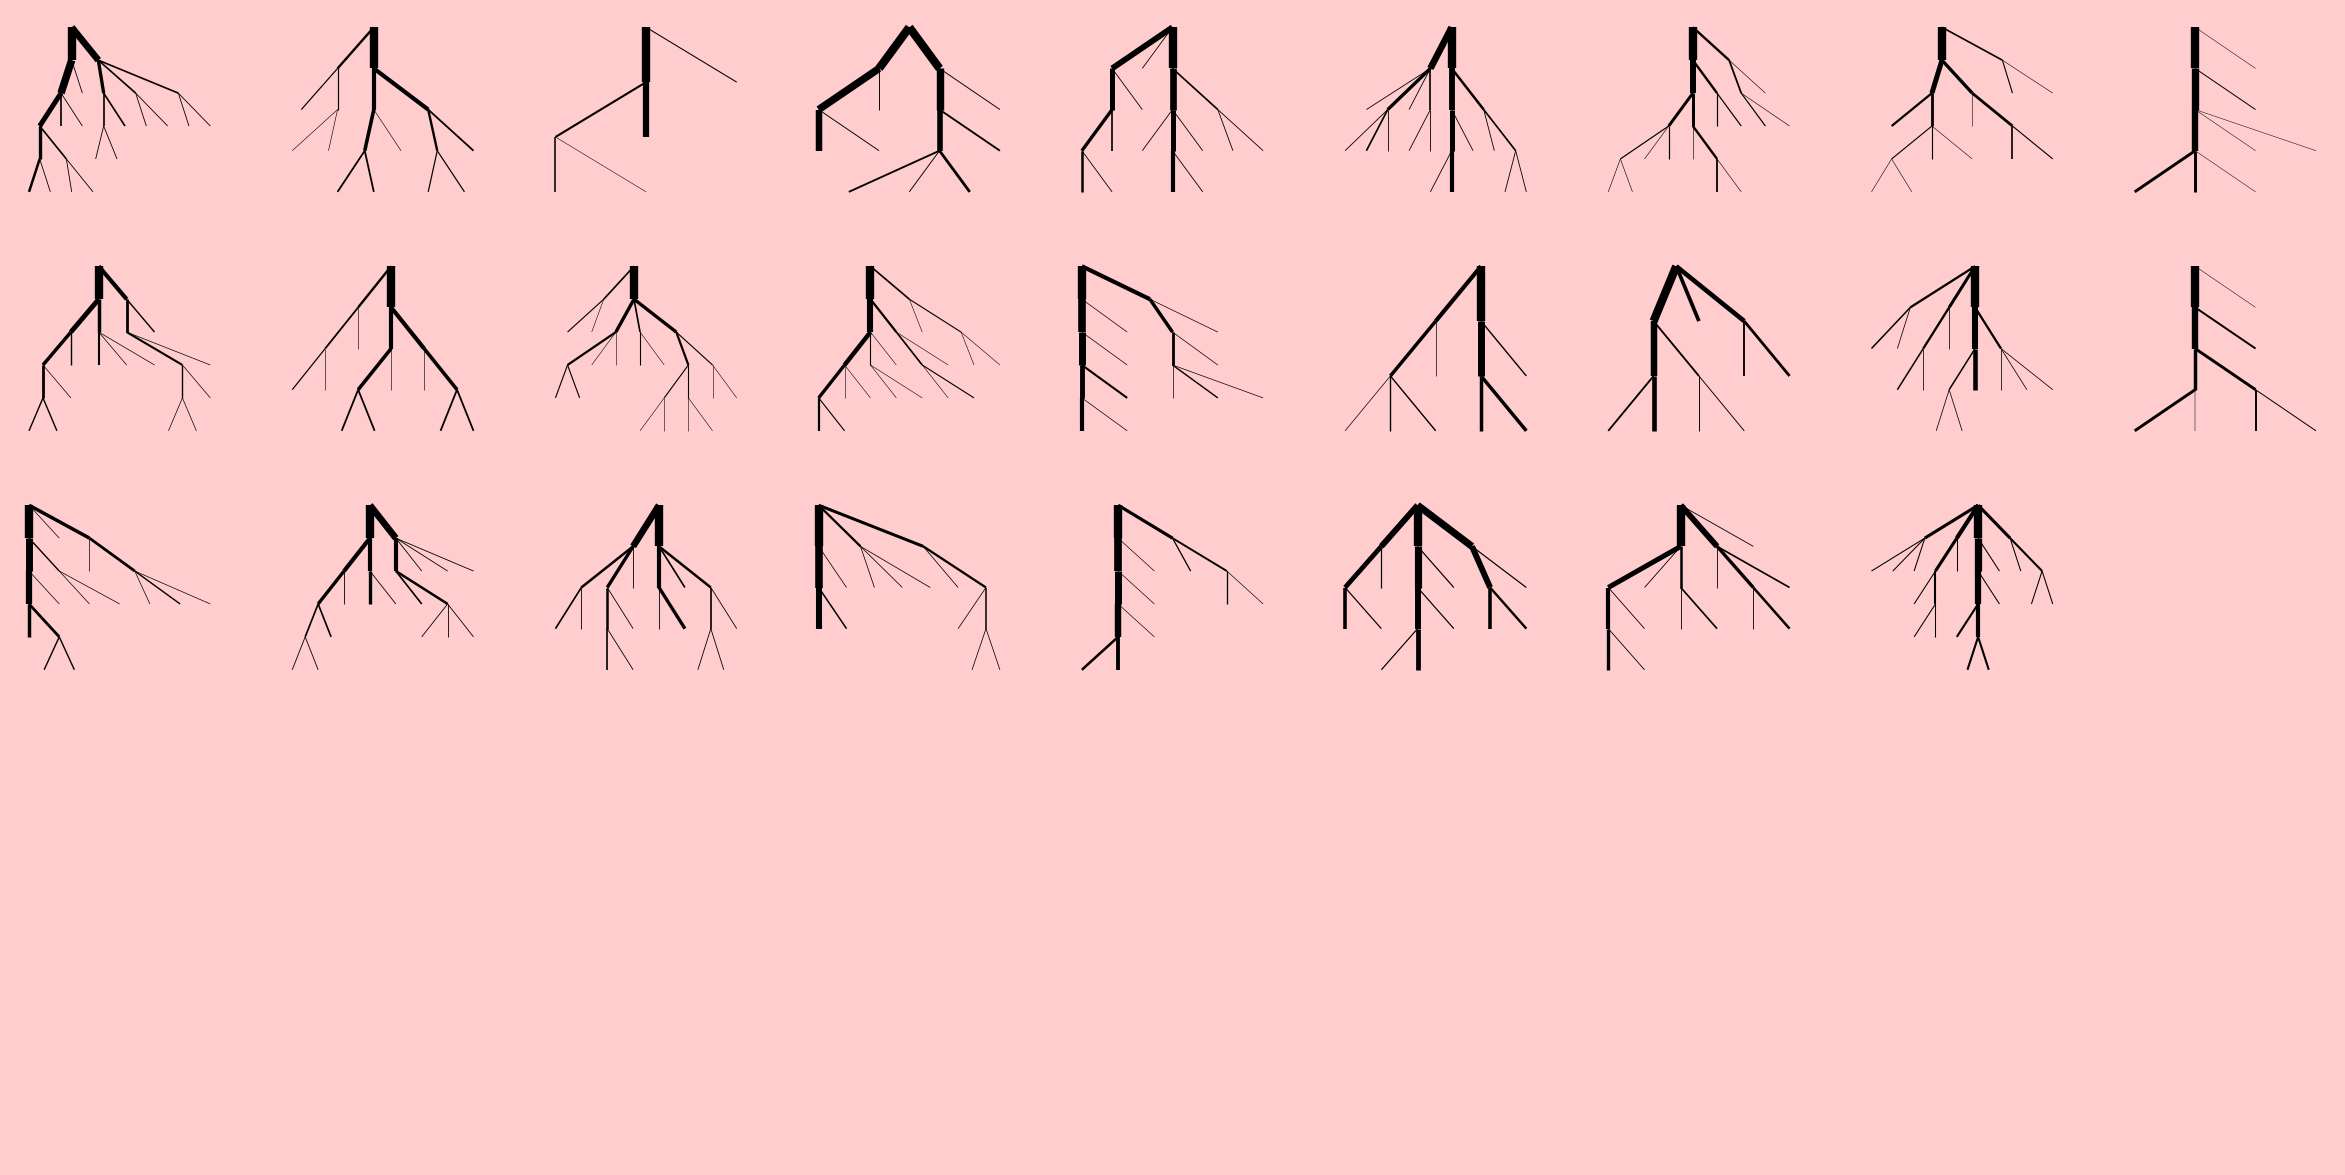

In [298]:
nodes_by_degree = {1: OBJECTS, 2: "BFSZV", 3: "CDEGHJMQXTU", 4: "R"}
nodes_by_obj = {1: OBJECTS, 2: "BFSZV"+"CDEGHJMQXTU"+"R"}

# print(len("".join([nodes_by_degree[n] for n  in nodes_by_degree])))

# silly
def hex_to_rgb_add_alpha(h, a):
    rgb = [int(h[i:i+2], 16)/255. for i in (0, 2, 4)]
    return (rgb[0], rgb[1], rgb[2], a)
    
COLORS = ["#FF5A5F", "#2a2d7c"]
fig, axes = plt.subplots(5, 9, figsize=(30,15), facecolor=hex_to_rgb_add_alpha("FF5A5F", 0.3))

row = -1
for n in nodes_by_obj:
    # row += 1
    for i, node in enumerate(nodes_by_obj[n]):
        if i % 9 == 0:
            row += 1

        G = example_tree_by_start_node[node]
        ax = axes[row][i % 9]
        plot_flow_tree(G, f"Start at {node}", ax, just_edges=True, no_title=True)

        

# i = 0
# for node in example_tree_by_start_node:
#     if node in OBJECTS: continue
#     G = example_tree_by_start_node[node]
#     # print(f"{i} -> row={i // 3}, col={(i % 6) + 3}")
#     ax = axes[i // 6][((i % 6) + 3)]
#     plot_flow_tree(G, f"Start at {node}", ax, just_edges=True, no_title=True)
#     i += 1

# fig.suptitle("Start-node Flow Trees")
for ax in axes.ravel():
    ax.set_axis_off()

plt.show()

#### helper fns

In [109]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    backbone_thickness = np.mean(weights) / max_weight
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    feature_names = ['num_nodes', 'depth', 'diameter', 'num_leaves', 'avg_branching', 'backbone_thickness']
    features = np.array([
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ])
    
    return feature_names, features

#### Node flow tree features

In [304]:
# Extract features for each tree
all_feature_names = None
all_features = []

for tree in all_tree_df["trees"]:
    # Get root node (any node with no incoming edges)
    root = 0
    
    # Extract features for this tree
    feature_names, features = extract_tree_features(tree, root)
    
    # Store feature names once
    if all_feature_names is None:
        all_feature_names = feature_names
        
    all_features.append(features)

# Convert to numpy array
tree_features = np.array(all_features)

# Add feature columns to dataframe
for i, name in enumerate(all_feature_names):
    all_tree_df[f"feature_{name}"] = tree_features[:,i]

num_nodes
Mann-Whitney U test p-value: nan
nan

Object num_nodes:
Mean: 16.2333
Variance: 14.8789

Non-object num_nodes:
Mean: nan
Variance: nan
 Multiple Comparison of Means - Tukey HSD, FWER=0.01 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      I      2.2 0.2563  -1.1114  5.5114  False
     A      K     -0.2    1.0  -3.5114  3.1114  False
     A      L    -1.35 0.8481  -4.6614  1.9614  False
     A      N    -5.85    0.0  -9.1614 -2.5386   True
     A      O     0.25    1.0  -3.0614  3.5614  False
     A      P     -2.8 0.0505  -6.1114  0.5114  False
     A      W      4.3 0.0001   0.9886  7.6114   True
     A      Y     -0.3    1.0  -3.6114  3.0114  False
     I      K     -2.4 0.1593  -5.7114  0.9114  False
     I      L    -3.55 0.0032  -6.8614 -0.2386   True
     I      N    -8.05    0.0 -11.3614 -4.7386   True
     I      O    -1.95 0.4198  -5.2614  1.3614  False
     I      P     -5.0    0.0  -8.3114 -1.688

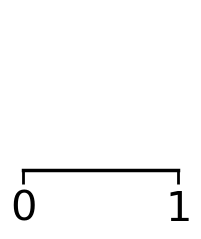

num_leaves
Mann-Whitney U test p-value: nan
nan

Object num_leaves:
Mean: 9.1667
Variance: 4.2833

Non-object num_leaves:
Mean: nan
Variance: nan
Multiple Comparison of Means - Tukey HSD, FWER=0.01 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      I      1.7 0.0117 -0.0477  3.4477  False
     A      K      0.3 0.9994 -1.4477  2.0477  False
     A      L    -0.65 0.9038 -2.3977  1.0977  False
     A      N     -2.7    0.0 -4.4477 -0.9523   True
     A      O     0.75 0.8076 -0.9977  2.4977  False
     A      P    -0.85 0.6788 -2.5977  0.8977  False
     A      W      2.8    0.0  1.0523  4.5477   True
     A      Y     0.15    1.0 -1.5977  1.8977  False
     I      K     -1.4 0.0794 -3.1477  0.3477  False
     I      L    -2.35 0.0001 -4.0977 -0.6023   True
     I      N     -4.4    0.0 -6.1477 -2.6523   True
     I      O    -0.95 0.5335 -2.6977  0.7977  False
     I      P    -2.55    0.0 -4.2977 -0.8023   True
     I

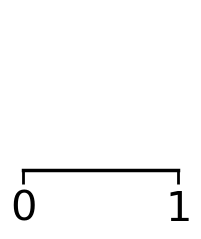

depth
Mann-Whitney U test p-value: nan
nan

Object depth:
Mean: 3.9000
Variance: 0.4233

Non-object depth:
Mean: nan
Variance: nan
Multiple Comparison of Means - Tukey HSD, FWER=0.01 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      I     -0.2 0.9673 -0.8515  0.4515  False
     A      K     -0.5 0.1093 -1.1515  0.1515  False
     A      L     -0.1 0.9997 -0.7515  0.5515  False
     A      N    -1.15    0.0 -1.8015 -0.4985   True
     A      O     -0.5 0.1093 -1.1515  0.1515  False
     A      P     -0.7 0.0031 -1.3515 -0.0485   True
     A      W     0.05    1.0 -0.6015  0.7015  False
     A      Y     -0.5 0.1093 -1.1515  0.1515  False
     I      K     -0.3 0.7403 -0.9515  0.3515  False
     I      L      0.1 0.9997 -0.5515  0.7515  False
     I      N    -0.95    0.0 -1.6015 -0.2985   True
     I      O     -0.3 0.7403 -0.9515  0.3515  False
     I      P     -0.5 0.1093 -1.1515  0.1515  False
     I      W     0.2

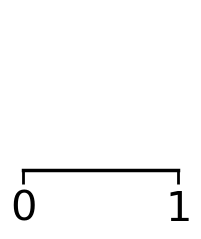

diameter
Mann-Whitney U test p-value: nan
nan

Object diameter:
Mean: 6.5722
Variance: 1.3559

Non-object diameter:
Mean: nan
Variance: nan
Multiple Comparison of Means - Tukey HSD, FWER=0.01 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      I     0.65  0.416 -0.4508  1.7508  False
     A      K      0.3 0.9844 -0.8008  1.4008  False
     A      L     -0.2  0.999 -1.3008  0.9008  False
     A      N    -1.45 0.0001 -2.5508 -0.3492   True
     A      O      0.5 0.7545 -0.6008  1.6008  False
     A      P     -0.5 0.7545 -1.6008  0.6008  False
     A      W     1.25 0.0013  0.1492  2.3508   True
     A      Y      0.1    1.0 -1.0008  1.2008  False
     I      K    -0.35 0.9597 -1.4508  0.7508  False
     I      L    -0.85 0.1047 -1.9508  0.2508  False
     I      N     -2.1    0.0 -3.2008 -0.9992   True
     I      O    -0.15 0.9999 -1.2508  0.9508  False
     I      P    -1.15 0.0047 -2.2508 -0.0492   True
     I      

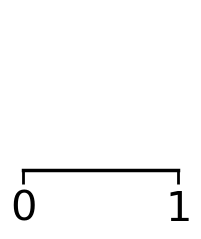

avg_branching
Mann-Whitney U test p-value: nan
nan

Object avg_branching:
Mean: 1.8686
Variance: 0.0014

Non-object avg_branching:
Mean: nan
Variance: nan
Multiple Comparison of Means - Tukey HSD, FWER=0.01 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      I   0.0122 0.8759  -0.019  0.0434  False
     A      K  -0.0046 0.9998 -0.0359  0.0266  False
     A      L  -0.0138 0.7841  -0.045  0.0175  False
     A      N  -0.0708    0.0  -0.102 -0.0396   True
     A      O   0.0015    1.0 -0.0298  0.0327  False
     A      P  -0.0314 0.0076 -0.0627 -0.0002   True
     A      W   0.0246 0.0903 -0.0066  0.0558  False
     A      Y  -0.0042 0.9999 -0.0355   0.027  False
     I      K  -0.0168 0.5434 -0.0481  0.0144  False
     I      L   -0.026 0.0584 -0.0572  0.0053  False
     I      N   -0.083    0.0 -0.1142 -0.0518   True
     I      O  -0.0107 0.9365  -0.042  0.0205  False
     I      P  -0.0436    0.0 -0.0749 -0.0124   Tr

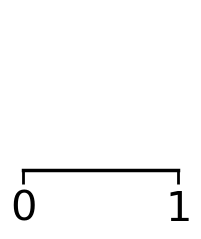

backbone_thickness
Mann-Whitney U test p-value: nan
nan

Object backbone_thickness:
Mean: 0.2858
Variance: 0.0035

Non-object backbone_thickness:
Mean: nan
Variance: nan
Multiple Comparison of Means - Tukey HSD, FWER=0.01 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      I   0.0242 0.8817 -0.0382  0.0866  False
     A      K   0.0267 0.8112 -0.0357  0.0891  False
     A      L   0.0192 0.9672 -0.0432  0.0816  False
     A      N   0.0833 0.0001  0.0209  0.1457   True
     A      O     0.05 0.0792 -0.0124  0.1124  False
     A      P    0.085    0.0  0.0226  0.1474   True
     A      W   0.0217 0.9334 -0.0407  0.0841  False
     A      Y     0.05 0.0792 -0.0124  0.1124  False
     I      K   0.0025    1.0 -0.0599  0.0649  False
     I      L   -0.005    1.0 -0.0674  0.0574  False
     I      N   0.0592 0.0158 -0.0032  0.1216  False
     I      O   0.0258 0.8367 -0.0366  0.0882  False
     I      P   0.0608 0.0114 -0.00

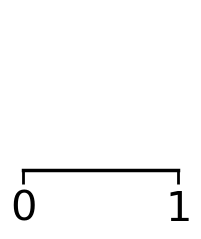

{'O_Y': [],
 'O_N': [('num_nodes', '0.0'),
  ('num_leaves', '0.0'),
  ('diameter', '0.0'),
  ('avg_branching', '0.0')],
 'O_K': [],
 'O_I': [],
 'O_W': [('num_nodes', '0.0004'), ('num_leaves', '0.0008')],
 'O_L': [],
 'O_A': [],
 'O_P': [('avg_branching', '0.0041')],
 'Y_N': [('num_nodes', '0.0'),
  ('num_leaves', '0.0'),
  ('diameter', '0.0'),
  ('avg_branching', '0.0')],
 'Y_K': [],
 'Y_I': [],
 'Y_W': [('num_nodes', '0.0'), ('num_leaves', '0.0'), ('diameter', '0.0047')],
 'Y_L': [],
 'Y_A': [],
 'Y_P': [],
 'N_K': [('num_nodes', '0.0'),
  ('num_leaves', '0.0'),
  ('diameter', '0.0'),
  ('avg_branching', '0.0')],
 'N_I': [('num_nodes', '0.0'),
  ('num_leaves', '0.0'),
  ('depth', '0.0'),
  ('diameter', '0.0'),
  ('avg_branching', '0.0')],
 'N_W': [('num_nodes', '0.0'),
  ('num_leaves', '0.0'),
  ('depth', '0.0'),
  ('diameter', '0.0'),
  ('avg_branching', '0.0')],
 'N_L': [('num_nodes', '0.0'),
  ('num_leaves', '0.0008'),
  ('depth', '0.0'),
  ('diameter', '0.0013'),
  ('avg_branchin

In [326]:
from matplotlib.gridspec import GridSpec

reverse = False

sigs = {f"{OBJECTS[i]}_{OBJECTS[j]}": [] for i in range(len(OBJECTS)) for j in range(i+1, len(OBJECTS))}

degree_order = "".join([nodes_by_degree[n] for n  in nodes_by_degree])

for fn in ["num_nodes", "num_leaves", "depth", "diameter", "avg_branching", "backbone_thickness"]:
    feature = f"feature_{fn}"
    print(fn)

    # Split nodes into OBJECTS and non-OBJECTS
    object_features = []
    objss = []
    nonobject_features = []
    # print(all_tree_df)
    for node in degree_order:
        # print(all_tree_df['node'])
        # print(all_tree_df[(all_tree_df["node"] == (node,))])
        # print(all_tree_df[(all_tree_df["reverse"] == reverse)])
        # # print(all_tree_df[all_tree_df['node'] == (node,)])
        node_trees = all_tree_df[(all_tree_df['node'] == (node,)) & (all_tree_df["reverse"] == reverse)]
        # print(node_trees)
        # print("AH")
        fts = node_trees[feature]
        
        if node in OBJECTS:
            object_features.extend(fts)
            for ff in fts:
                objss.append(node)
        else:
            nonobject_features.extend(fts)

    # Perform statistical test
    stat, pval = stats.mannwhitneyu(object_features, nonobject_features)
    print(f"Mann-Whitney U test p-value: {pval:.4f}")
    print(stat)
    # Print mean and variance for each group
    print(f"\nObject {fn}:")
    print(f"Mean: {np.mean(object_features):.4f}")
    print(f"Variance: {np.var(object_features):.4f}")

    print(f"\nNon-object {fn}:") 
    print(f"Mean: {np.mean(nonobject_features):.4f}")
    print(f"Variance: {np.var(nonobject_features):.4f}")

    tukey_start = pairwise_tukeyhsd(object_features, objss, alpha=0.05/6)
    # Print only significant differences
    summary = tukey_start.summary()
    print(summary)
    # significant_rows = [i for i, reject in enumerate(tukey_start.reject) if bool(reject)]
    print("Significant pairs:")
    for row in summary[1:]:
        if str(row[-1]) == "True":
            pair = str(row[0]) + "_" + str(row[1])
            if pair not in sigs:
                pair = pair[2]+pair[1]+pair[0]
            sigs[pair].append((fn, str(row[3])))
            print(row[0], row[1], str(row[3]))


    # Set up figure and grid
    fig = plt.figure(figsize=(2, 4))  # Wider figure to accommodate 9 subplots
    gs = GridSpec(4, 1, figure=fig)#, height_ratios=[2,2,2,2,2,2,2,2,2,.2], hspace=.5)  # 1 row, 9 columns


    # Store diameters for plotting
    all_features = []
    for deg in nodes_by_obj:
        temp = []
        for node in nodes_by_degree[deg]:
            node_trees = all_tree_df[all_tree_df['node'] == (node,) & (all_tree_df["reverse"] == reverse)]
            temp.extend(node_trees[feature])
        all_features.append(temp)


    COLORS = ["#FF5A5F", "#2a2d7c"]
    for i, node in enumerate(nodes_by_obj):
        ax = fig.add_subplot(gs[i])

        sns.boxplot(all_features[i], orient='h', color=COLORS[i], linewidth=4, ax=ax)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.yaxis.set_visible(False)
        ax.xaxis.set_visible(False)
        
        ax.patch.set_visible(False)
        ax.set_facecolor('none') 


    ax.xaxis.set_visible(True)

    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.spines['bottom'].set_position(('outward', 10))

    ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    # plt.xticks([0, 5, 10])
    plt.xlabel("")

    plt.show()

sigs

In [327]:
nice_table = {"num_nodes": "\# nodes", "num_leaves": "\# leaves", "depth": "depth", "diameter": "diameter", "avg_branching": "branching", "backbone_thickness": "backbone",  }
for pair in sigs:
    ss = sigs[pair]
    sigs_str = ""
    ps_str = ""
    for s,p in ss:
        sigs_str += nice_table[s]
        if float(p) <0.001:
            sigs_str += "*, "
        else:
            sigs_str += f" ($p$={float(p):0.4f}), "
    print("$\\mathcal{" + pair[0] + "}$ vs $\\mathcal{" +pair[-1]+ "}$ &", len(ss),"& " + sigs_str +"\\\\")


$\mathcal{O}$ vs $\mathcal{Y}$ & 0 & \\
$\mathcal{O}$ vs $\mathcal{N}$ & 4 & \# nodes*, \# leaves*, diameter*, branching*, \\
$\mathcal{O}$ vs $\mathcal{K}$ & 0 & \\
$\mathcal{O}$ vs $\mathcal{I}$ & 0 & \\
$\mathcal{O}$ vs $\mathcal{W}$ & 2 & \# nodes*, \# leaves*, \\
$\mathcal{O}$ vs $\mathcal{L}$ & 0 & \\
$\mathcal{O}$ vs $\mathcal{A}$ & 0 & \\
$\mathcal{O}$ vs $\mathcal{P}$ & 1 & branching ($p$=0.0041), \\
$\mathcal{Y}$ vs $\mathcal{N}$ & 4 & \# nodes*, \# leaves*, diameter*, branching*, \\
$\mathcal{Y}$ vs $\mathcal{K}$ & 0 & \\
$\mathcal{Y}$ vs $\mathcal{I}$ & 0 & \\
$\mathcal{Y}$ vs $\mathcal{W}$ & 3 & \# nodes*, \# leaves*, diameter ($p$=0.0047), \\
$\mathcal{Y}$ vs $\mathcal{L}$ & 0 & \\
$\mathcal{Y}$ vs $\mathcal{A}$ & 0 & \\
$\mathcal{Y}$ vs $\mathcal{P}$ & 0 & \\
$\mathcal{N}$ vs $\mathcal{K}$ & 4 & \# nodes*, \# leaves*, diameter*, branching*, \\
$\mathcal{N}$ vs $\mathcal{I}$ & 5 & \# nodes*, \# leaves*, depth*, diameter*, branching*, \\
$\mathcal{N}$ vs $\mathcal{W}$ & 5 

In [282]:
sigs_by_node = {x: [] for x in OBJECTS}

for pair in sigs:
    if len(sigs[pair]) >= 4:
        sigs_by_node[pair[0]].append(pair)
        sigs_by_node[pair[2]].append(pair)

for node in sigs_by_node:
    print(node, sigs_by_node[node])

O ['O_K', 'O_W']
Y ['Y_P']
N []
K ['O_K', 'K_W']
I ['I_W']
W ['O_W', 'K_W', 'I_W', 'W_L']
L ['W_L']
A []
P ['Y_P']


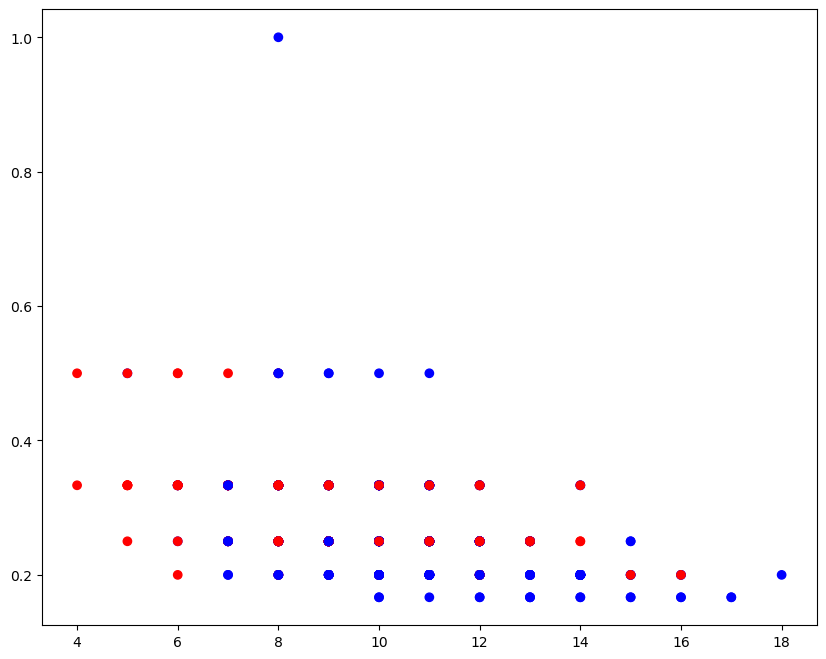

PearsonRResult(statistic=-0.4728591963399017, pvalue=2.510368317355208e-30)

In [113]:
plt.figure(figsize=(10,8))
# print(pca_result[:,0].shape)
# print(len(diameters))
# scatter = plt.scatter(pca_result[:,0], all_tree_df["feature_avg_branching"], 
#                      c=[1 if n in OBJECTS else 0 for n in all_tree_df["node"].str[0]], 
#                      cmap='bwr')
scatter = plt.scatter(all_tree_df['feature_num_leaves'], all_tree_df['feature_backbone_thickness'], 
                     c=[1 if n in OBJECTS else 0 for n in all_tree_df["node"].str[0]], 
                     cmap='bwr')

plt.show()

stats.pearsonr(all_tree_df['feature_num_leaves'], all_tree_df["feature_backbone_thickness"])

In [114]:
node_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
node_flow_tree_embedder.fit(np.array(all_tree_df["trees"]))

# Extract features for each tree
all_embeddings = []

# Get embeddings for each tree
all_tree_embeddings = node_flow_tree_embedder.infer(np.array(all_tree_df["trees"]))

# Add single column with full embedding vector
all_tree_df["embedding"] = [emb for emb in all_tree_embeddings]

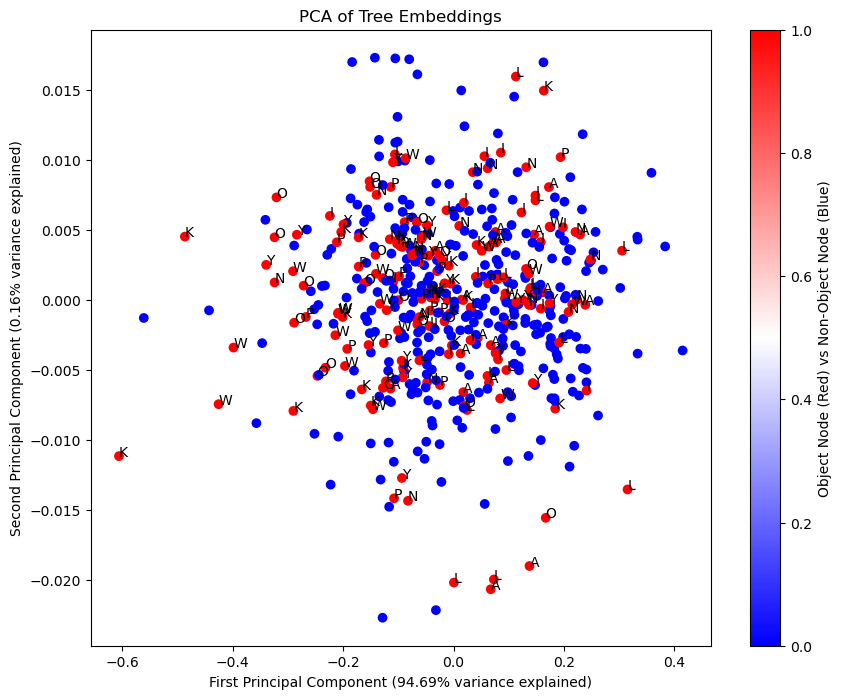


First Principal Component:
26525.0
Mann-Whitney U test p-value: 1.243e-02
Significantly different

Means:
Object nodes PC1: -0.026
Non-object nodes PC1: 0.014
Object nodes PC2: 0.000
Non-object nodes PC2: -0.000

Standard Deviations:
Object nodes PC1: 0.156
Non-object nodes PC1: 0.148
Object nodes PC2: 0.006
Non-object nodes PC2: 0.006

Second Principal Component:
Mann-Whitney U test p-value: 2.834e-01
Not significantly different


In [115]:

# Convert embeddings to a matrix for PCA
embedding_matrix = np.array(all_tree_df["embedding"].tolist())

# Perform PCA
pca = PCA(n_components=4)
pca_result = pca.fit_transform(embedding_matrix)

# Create scatter plot
plt.figure(figsize=(10,8))
scatter = plt.scatter(pca_result[:,0], pca_result[:,1], 
                     c=[1 if n in OBJECTS else 0 for n in all_tree_df["node"].str[0]], 
                     cmap='bwr')

# Add labels for object nodes
for idx, row in all_tree_df.iterrows():
    if row["node"][0] in OBJECTS:
        plt.annotate(row["node"][0], (pca_result[idx,0], pca_result[idx,1]))

plt.title('PCA of Tree Embeddings')
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.2%} variance explained)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.2%} variance explained)')
plt.colorbar(scatter, label='Object Node (Red) vs Non-Object Node (Blue)')
plt.show()

# Separate embeddings for object and non-object nodes
object_embeddings = pca_result[[n[0] in OBJECTS for n in all_tree_df["node"]]]
non_object_embeddings = pca_result[[n[0] not in OBJECTS for n in all_tree_df["node"]]]

# Perform statistical test (Mann-Whitney U test) on both principal components

# Test PC1
stat1, pval1 = stats.mannwhitneyu(object_embeddings[:,0], non_object_embeddings[:,0])
print("\nFirst Principal Component:")
print(stat1)
print(f"Mann-Whitney U test p-value: {pval1:.3e}")
print("Significantly different" if pval1 < 0.05 else "Not significantly different")

# Calculate means and standard deviations for both groups
print("\nMeans:")
print(f"Object nodes PC1: {np.mean(object_embeddings[:,0]):.3f}")
print(f"Non-object nodes PC1: {np.mean(non_object_embeddings[:,0]):.3f}")
print(f"Object nodes PC2: {np.mean(object_embeddings[:,1]):.3f}") 
print(f"Non-object nodes PC2: {np.mean(non_object_embeddings[:,1]):.3f}")

print("\nStandard Deviations:")
print(f"Object nodes PC1: {np.std(object_embeddings[:,0]):.3f}")
print(f"Non-object nodes PC1: {np.std(non_object_embeddings[:,0]):.3f}")
print(f"Object nodes PC2: {np.std(object_embeddings[:,1]):.3f}")
print(f"Non-object nodes PC2: {np.std(non_object_embeddings[:,1]):.3f}")


# Test PC2  
stat2, pval2 = stats.mannwhitneyu(object_embeddings[:,1], non_object_embeddings[:,1])
print("\nSecond Principal Component:")
print(f"Mann-Whitney U test p-value: {pval2:.3e}")
print("Significantly different" if pval2 < 0.05 else "Not significantly different")



## 3. More detail for object start-node

In [116]:
# Create empty DataFrame to store all tree information
tree_df = pd.DataFrame(columns=[
    'node_type',      # 'start' or 'end'
    'node',           # the actual node label
    'trajectory_type', # 'all', 'winner', or 'loser'
    'mean_accuracy',   # mean accuracy for this group
    'trees'           # list of bootstrapped trees
])

ttt = []
# Function to generate bootstrapped trees
def generate_bootstrap_trees(group, k_fold=20, sample_frac=0.7, reverse_trajs=False):
    trees = []
    for _ in range(k_fold):
        sampled_group = group.sample(frac=sample_frac)
        # Randomly select 58 samples if group is larger than that
        if len(sampled_group) > 58:
            sampled_group = sampled_group.sample(n=58)
        trajs = generate_trajs_from_df(sampled_group)
        if reverse_trajs:
            trajs = [list(reversed(t)) for t in trajs]
        ttt.append(len(trajs))
        G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)
    return trees

# Generate trees for start nodes
example_tree_by_start_node = {}
for traj_type, df_subset in [
    ('all', test_df),
    ('winner', test_df[test_df['accuracy']]),
    ('loser', test_df[~test_df['accuracy']])
]:
    for start_node, group in df_subset.groupby(['StartAt']):
        mean_acc = np.mean(group['path_mean_acc'])
        trees = generate_bootstrap_trees(group)

        tree_df = pd.concat([tree_df, pd.DataFrame({
            'node_type': ['start'] * len(trees),
            'node': [start_node] * len(trees), 
            'trajectory_type': [traj_type] * len(trees),
            'mean_accuracy': [mean_acc] * len(trees),
            'trees': trees
        })], ignore_index=True)

# Generate trees for end nodes
test_df['ending_node'] = test_df['paths'].apply(lambda x: x[-1])
for traj_type, df_subset in [
    ('all', test_df),
    ('winner', test_df[test_df['ending_node'] == test_df['EndAt']]),
    ('loser', test_df[test_df['ending_node'] != test_df['EndAt']])
]:
    for end_node, group in df_subset.groupby(['ending_node']):
        if end_node[0] not in OBJECTS:
            continue
        mean_acc = np.mean(group['path_mean_acc'])
        trees = generate_bootstrap_trees(group, reverse_trajs=True)
        
        tree_df = pd.concat([tree_df, pd.DataFrame({
            'node_type': ['end'] * len(trees),
            'node': [end_node] * len(trees),
            'trajectory_type': [traj_type] * len(trees),
            'mean_accuracy': [mean_acc] * len(trees),
            'trees': trees
        })], ignore_index=True)

print(np.mean(ttt))
print(max(ttt), min(ttt))

57.96296296296296
58 56


#### Old w/ start, winner, loser

In [117]:
## BY START
# All trajectories
start_tree_dict = {}
for start_node, group in test_df.groupby(["StartAt"]):
    trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    start_tree_dict[start_node] = [new_G, np.mean(group["path_mean_acc"])]

# # Winners only
# start_winner_dict = {}
# for start_node, group in test_df[test_df["accuracy"]].groupby(["StartAt"]):
#     trajs = generate_trajs_from_df(group)
#     G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
#     new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
#     start_winner_dict[start_node] = [new_G, np.mean(group["path_mean_acc"])]

# # Losers only  
# start_loser_dict = {}
# for start_node, group in test_df[~test_df["accuracy"]].groupby(["StartAt"]):
#     trajs = generate_trajs_from_df(group)
#     G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
#     new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
#     start_loser_dict[start_node] = [new_G, np.mean(group["path_mean_acc"])]

dict_keys([('A',), ('I',), ('K',), ('L',), ('N',), ('O',), ('P',), ('W',), ('Y',)])


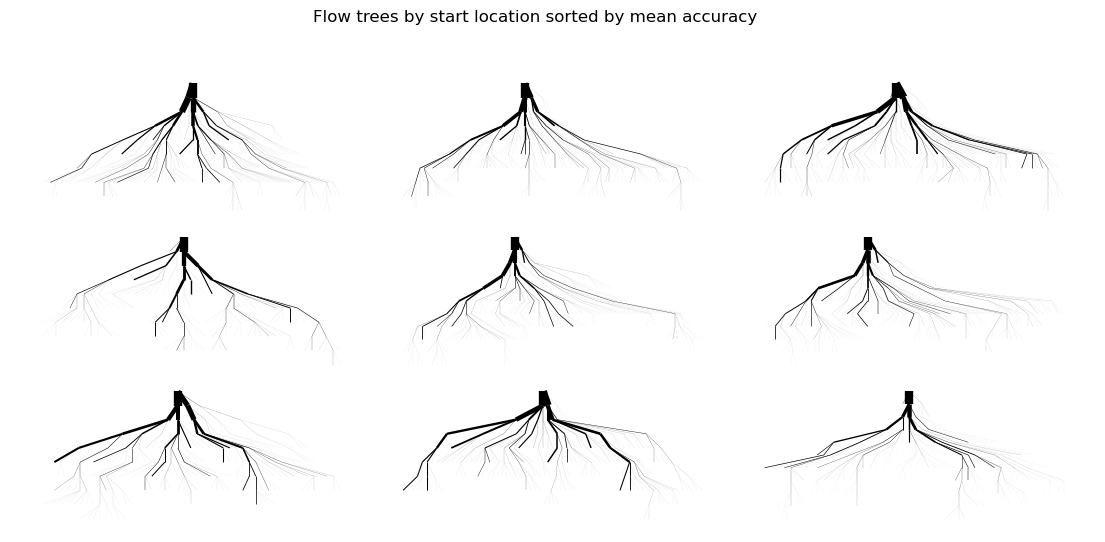

In [118]:
print(start_tree_dict.keys())
# Plot all trajectories
start_accs = [v[1] for v in start_tree_dict.values()]
start_graphs = [v[0] for v in start_tree_dict.values()]
start_nodes = list(start_tree_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(14,6))
plt.subplots_adjust(wspace=0, hspace=0)  # Remove spacing between subplots
sorted_order = [x for x in sorted(range(len(start_accs)), key=lambda x: start_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = start_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    plot_flow_tree(G, "", ax, just_edges=True)  # Removed title from individual plots
fig.suptitle("Flow trees by start location sorted by mean accuracy")
fig.savefig("figures/start_flow_trees_by_acc.png")
plt.show()

# # Plot winners
# start_winner_accs = [v[1] for v in start_winner_dict.values()]
# start_winner_graphs = [v[0] for v in start_winner_dict.values()]
# start_winner_nodes = list(start_winner_dict.keys())

# fig, axes = plt.subplots(3, 3, figsize=(20,10))
# # sorted_order = [x for x in sorted(range(len(start_winner_accs)), key=lambda x: start_winner_accs[x])]
# for i, tree_index in enumerate(sorted_order):
#     G = start_winner_graphs[tree_index]
#     ax = axes[i // 3][i % 3]
#     plot_flow_tree(G, f"Start at {start_winner_nodes[tree_index]} {start_winner_accs[tree_index]:.2f}", ax, just_edges=True)
# fig.suptitle("WINNERS ONLY: Flow trees by start location sorted by mean accuracy") 
# fig.savefig("figures/start_flow_trees_by_acc-winners.png")
# plt.show()

# # Plot losers
# start_loser_accs = [v[1] for v in start_loser_dict.values()]
# start_loser_graphs = [v[0] for v in start_loser_dict.values()]
# start_loser_nodes = list(start_loser_dict.keys())

# fig, axes = plt.subplots(3, 3, figsize=(20,10))
# # sorted_order = [x for x in sorted(range(len(start_loser_accs)), key=lambda x: start_loser_accs[x])]
# for i, tree_index in enumerate(sorted_order):
#     G = start_loser_graphs[tree_index]
#     ax = axes[i // 3][i % 3]
#     plot_flow_tree(G, f"Start at {start_loser_nodes[tree_index]} {start_loser_accs[tree_index]:.2f}", ax, just_edges=True)
# fig.suptitle("LOSERS ONLY: Flow trees by start location sorted by mean accuracy")
# fig.savefig("figures/start_flow_trees_by_acc-losers.png")
# plt.show()

### End-node Flow Trees

In [119]:
## BY END
test_df["ending_node"] = test_df["paths"].apply(lambda x: x[-1])

# All trajectories
end_tree_dict = {}
for end_node, group in test_df.groupby(["ending_node"]):    
    if end_node[0] not in OBJECTS: continue
    
    trajs = generate_trajs_from_df(group)
    rev_trajs = [list(reversed(t)) for t in trajs]
    G = generate_flow_tree_from_trajs(rev_trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    end_tree_dict[end_node] = [new_G, np.mean(group["path_mean_acc"])]

# Intentional/winner only
end_winner_dict = {}
for end_node, group in test_df[(test_df["ending_node"] == test_df["EndAt"])].groupby(["ending_node"]):    
    if end_node[0] not in OBJECTS: continue
    
    trajs = generate_trajs_from_df(group)
    rev_trajs = [list(reversed(t)) for t in trajs]
    G = generate_flow_tree_from_trajs(rev_trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    end_winner_dict[end_node] = [new_G, np.mean(group["path_mean_acc"])]

# Unintentional/losers only  # Intentional/winner only
end_loser_dict = {}
for end_node, group in test_df[~(test_df["ending_node"] == test_df["EndAt"])].groupby(["ending_node"]):    
    if end_node[0] not in OBJECTS: continue
    
    trajs = generate_trajs_from_df(group)
    rev_trajs = [list(reversed(t)) for t in trajs]
    G = generate_flow_tree_from_trajs(rev_trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    end_loser_dict[end_node] = [new_G, np.mean(group["path_mean_acc"])]

### Plot End-node Flow Trees

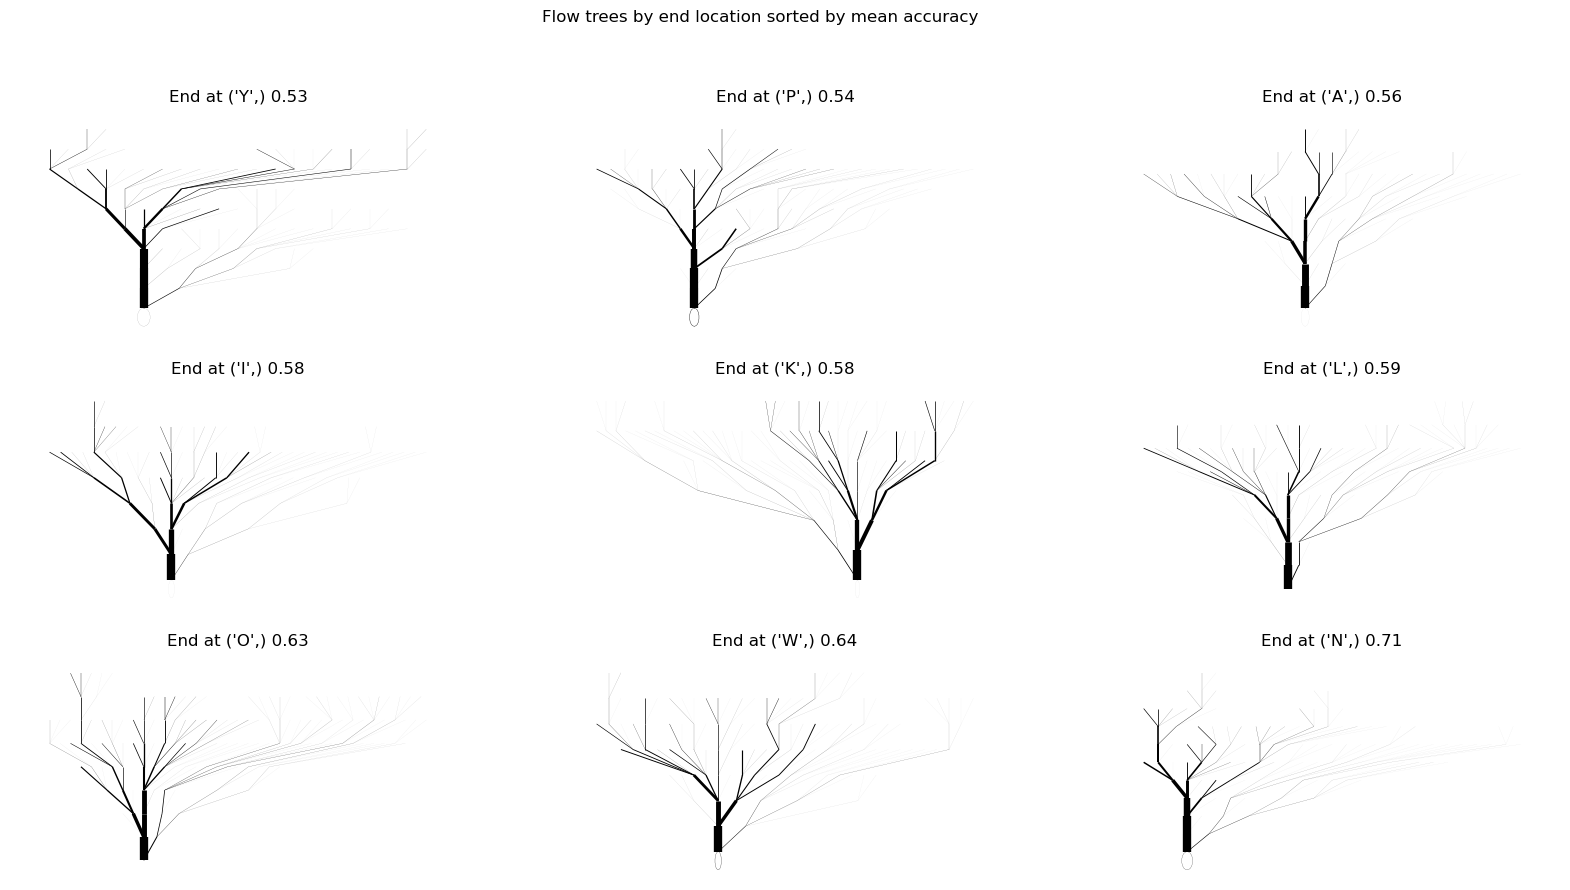

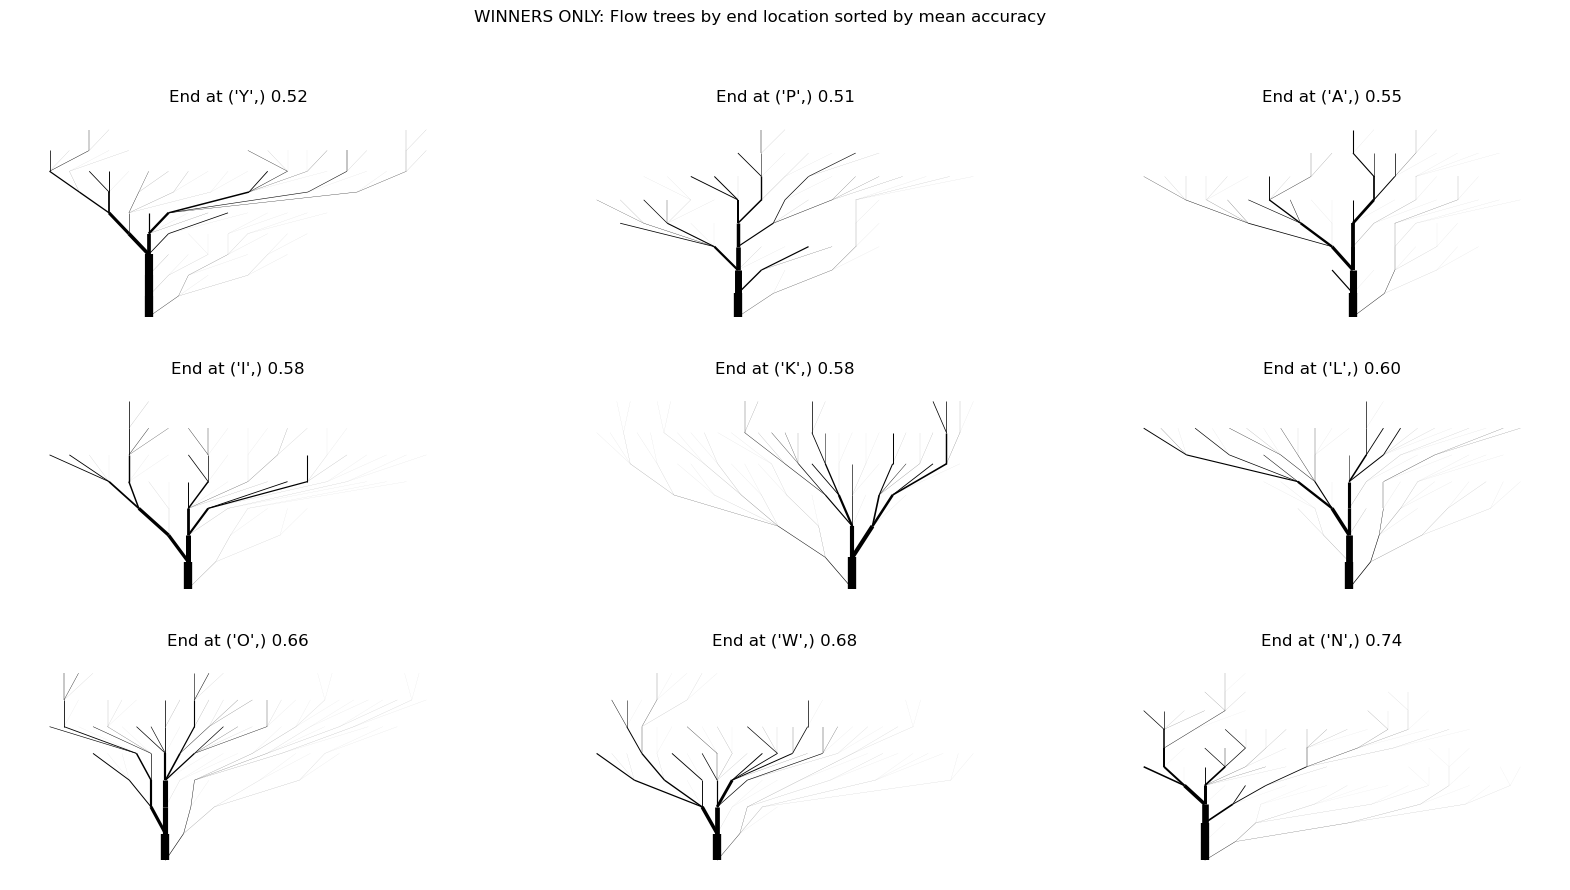

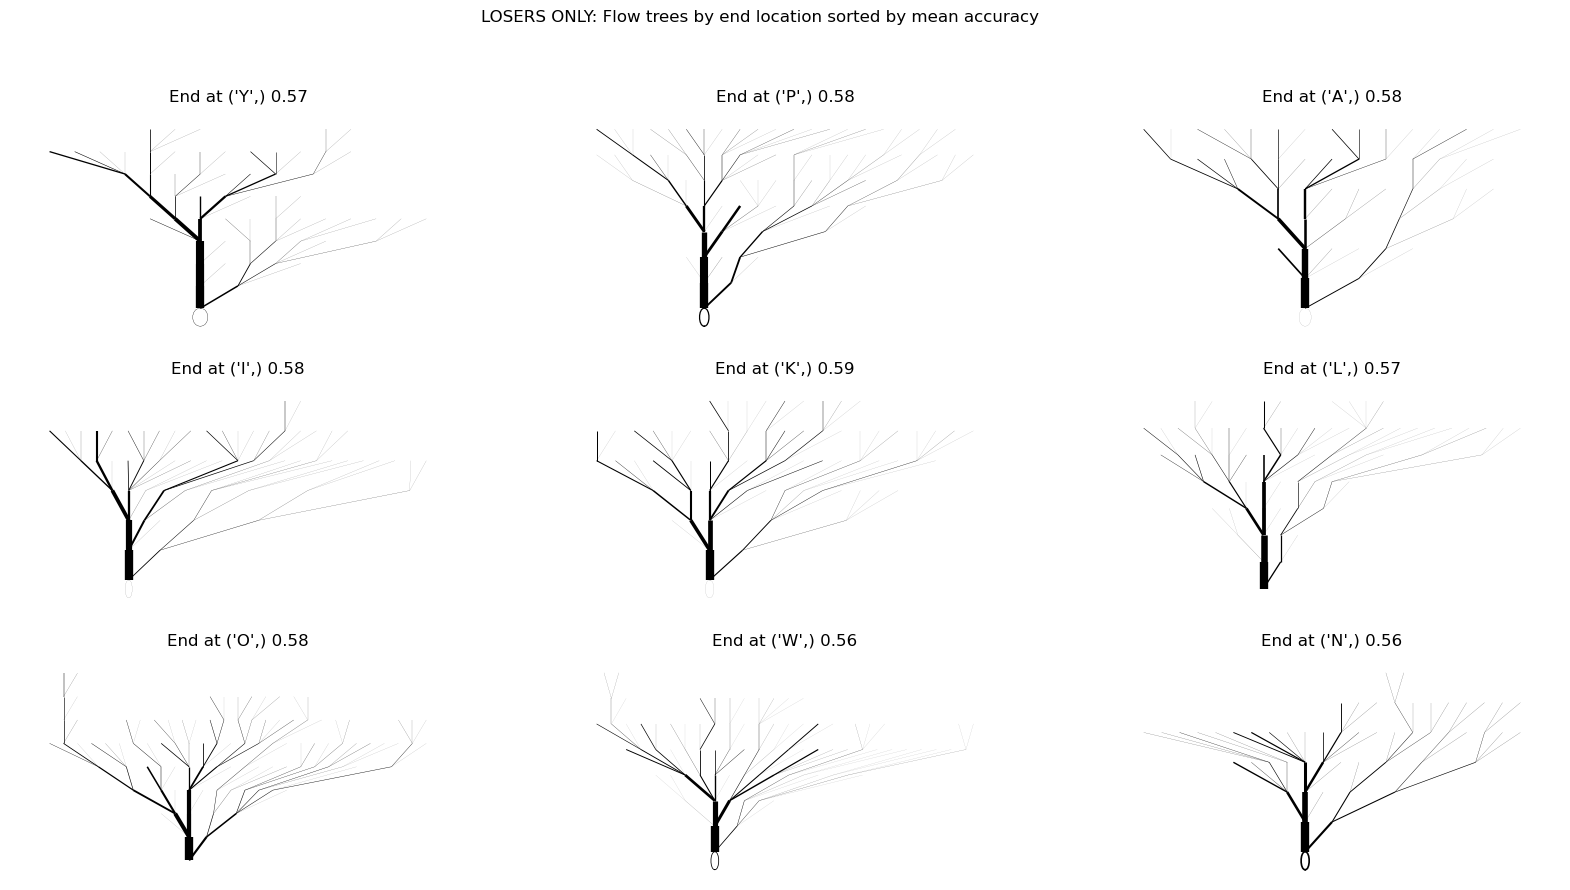

In [120]:
# Plot all trajectories
end_accs = [v[1] for v in end_tree_dict.values()]
end_graphs = [v[0] for v in end_tree_dict.values()]
end_nodes = list(end_tree_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
sorted_order = [x for x in sorted(range(len(end_accs)), key=lambda x: end_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = end_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    ax.invert_yaxis() # Flip y-axis
    plot_flow_tree(G, f"End at {end_nodes[tree_index]} {end_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("Flow trees by end location sorted by mean accuracy")
fig.savefig("figures/end_flow_trees_by_acc.png")
plt.show()

# Plot winners
end_winner_accs = [v[1] for v in end_winner_dict.values()]
end_winner_graphs = [v[0] for v in end_winner_dict.values()]
end_winner_nodes = list(end_winner_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
# sorted_order = [x for x in sorted(range(len(end_winner_accs)), key=lambda x: end_winner_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = end_winner_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    ax.invert_yaxis() # Flip y-axis
    plot_flow_tree(G, f"End at {end_winner_nodes[tree_index]} {end_winner_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("WINNERS ONLY: Flow trees by end location sorted by mean accuracy") 
fig.savefig("figures/end_flow_trees_by_acc-winners.png")
plt.show()

# Plot losers
end_loser_accs = [v[1] for v in end_loser_dict.values()]
end_loser_graphs = [v[0] for v in end_loser_dict.values()]
end_loser_nodes = list(end_loser_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
# sorted_order = [x for x in sorted(range(len(end_loser_accs)), key=lambda x: end_loser_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = end_loser_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    ax.invert_yaxis() # Flip y-axis
    plot_flow_tree(G, f"End at {end_loser_nodes[tree_index]} {end_loser_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("LOSERS ONLY: Flow trees by end location sorted by mean accuracy")
fig.savefig("figures/end_flow_trees_by_acc-losers.png")
plt.show()


# canyou gather people's intention from here? like look at subtrees and cluster???
# real human movement

## 22. Object Start v Rev End Flow Tree

In [302]:
## Make node trees for everything
# Create empty DataFrame to store all tree information
all_tree_df = pd.DataFrame(columns=[
    "node",           # the actual node label
    "trees",           # list of bootstrapped trees
    "reverse"
])

def process_path(path):
    states = path.split()
    states[-1] = "."+states[-1]
    states = collapse_traj(states)
    return(states)

trajs = [process_path(x) for x in test_df["paths"]]
traj_dict = {x: [] for x in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"}

for traj in trajs:
    for i in range(len(traj)-8): # want min path length 4/5
        traj_dict[traj[i]].append(traj[i:i+7])

s_example_tree_by_start_node = {}
r_example_tree_by_start_node = {}

k_fold = 20
for node in OBJECTS:
    # START NODE FLOW TREES
    trees = []
    for _ in range(k_fold):
        sampled_trajs = traj_dict[node]
        if len(sampled_trajs) > 17:
            sampled_indices = np.random.choice(len(sampled_trajs), size=18, replace=False)
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
        else:
            print(len(sampled_trajs))
        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)
        
    s_example_tree_by_start_node[node] = trees[0]

    all_tree_df = pd.concat([all_tree_df, pd.DataFrame({
        'node': [(node,)] * len(trees), 
        'trees': trees,
        "reverse": False
    })], ignore_index=True)

    # REV END NODE FLOW TREES
    group = test_df[test_df["ending_node"] == node]
    trajs = generate_trajs_from_df(group)
    rev_trajs = [list(reversed(t))[:7] for t in trajs]

    trees = []
    for _ in range(k_fold):
        sampled_trajs = rev_trajs
        if len(sampled_trajs) > 17:
            sampled_indices = np.random.choice(len(sampled_trajs), size=18, replace=False)
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
        else:
            print(len(sampled_trajs))

        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)

    r_example_tree_by_start_node[node] = trees[0]

    all_tree_df = pd.concat([all_tree_df, pd.DataFrame({
        'node': [(node,)] * len(trees), 
        'trees': trees,
        "reverse": True
    })], ignore_index=True)


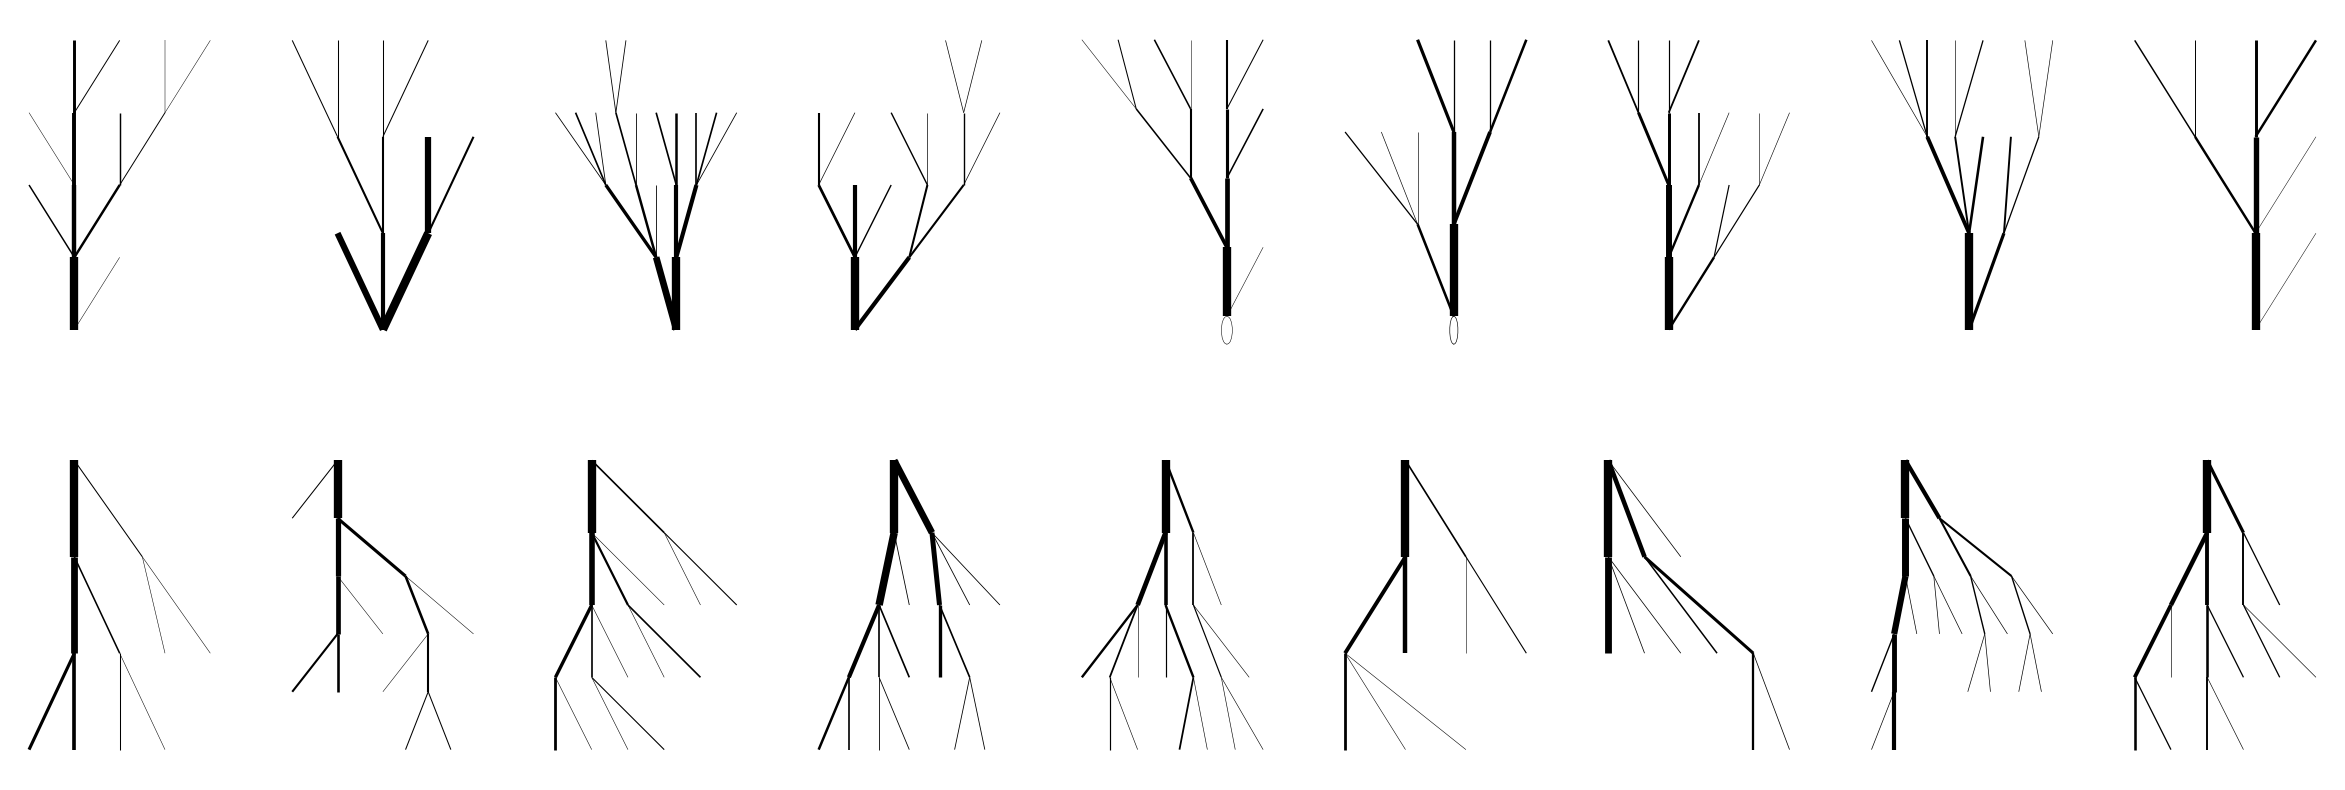

In [246]:
fig, axes = plt.subplots(2, 9, figsize=(30,10))

for i, node in enumerate("ALKOINPWY"):
    G = r_example_tree_by_start_node[node]
    ax = axes[0][i % 9]
    ax.invert_yaxis()
    plot_flow_tree(G, f"Start at {node}", ax, just_edges=True, no_title=True)


for i, node in enumerate("ALKOINPWY"):
    G = s_example_tree_by_start_node[node]
    ax = axes[1][i % 9]
    plot_flow_tree(G, f"Start at {node}", ax, just_edges=True, no_title=True)


        
for ax in axes.ravel():
    ax.set_axis_off()

plt.show()

In [248]:
# Extract features for each tree
all_feature_names = None
all_features = []

for tree in all_tree_df["trees"]:
    # Get root node (any node with no incoming edges)
    root = 0
    
    # Extract features for this tree
    feature_names, features = extract_tree_features(tree, root)
    
    # Store feature names once
    if all_feature_names is None:
        all_feature_names = feature_names
        
    all_features.append(features)

# Convert to numpy array
tree_features = np.array(all_features)

# Add feature columns to dataframe
for i, name in enumerate(all_feature_names):
    all_tree_df[f"feature_{name}"] = tree_features[:,i]

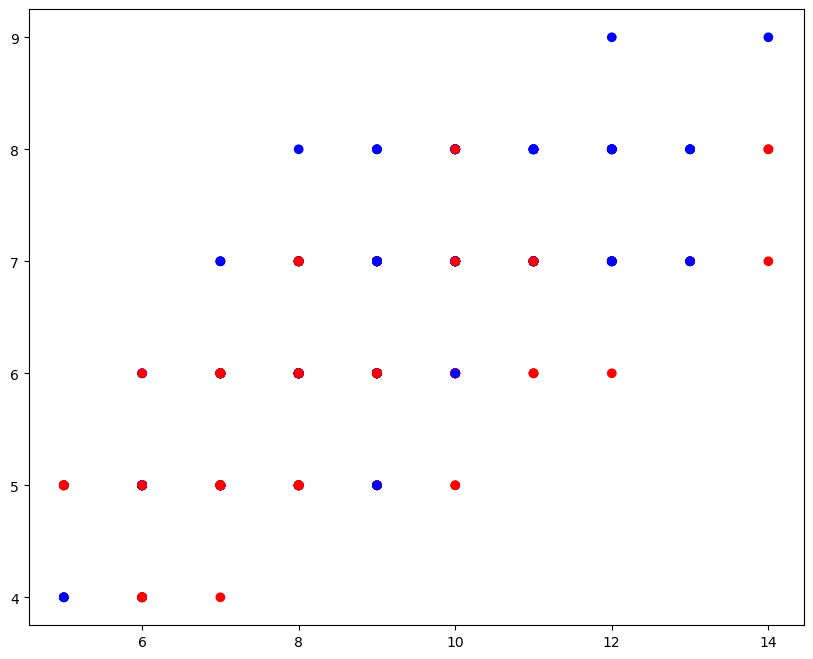

PearsonRResult(statistic=-0.40469935301333626, pvalue=1.2789087959890507e-15)

In [180]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(all_tree_df['feature_num_leaves'], all_tree_df['feature_diameter'], 
                     c=[1 if n else 0 for n in all_tree_df["reverse"]], 
                     cmap='bwr')

plt.show()

stats.pearsonr(all_tree_df['feature_num_leaves'], all_tree_df["feature_backbone_thickness"])

num_nodes
Mann-Whitney U test p-value: 0.0012
19386.0

Start num_nodes:
Mean: 15.8333
Variance: 12.2833

End num_nodes:
Mean: 14.7222
Variance: 11.4340
One-way ANOVA results for Start Nodes:
F=22.5381 p=0.00000
One-way ANOVA results for End Nodes:
F=23.7938 p=0.00000
One-way ANOVA results for Start v. End Nodes:
F=9.3176 p=0.00244

Full Model (Direction and Node):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.2500      0.183     77.970      0.000      13.891      14.609
x1            -1.1111      0.287     -3.869      0.000      -1.676      -0.546
x2             4.5556      0.407     11.203      0.000       3.756       5.355
x3            -0.2444      0.407     -0.601      0.548      -1.044       0.555
x4            -2.2444      0.407     -5.519      0.000      -3.044      -1.445
x5             3.9556      0.407      9.727      0.000       3.156       4.755
x

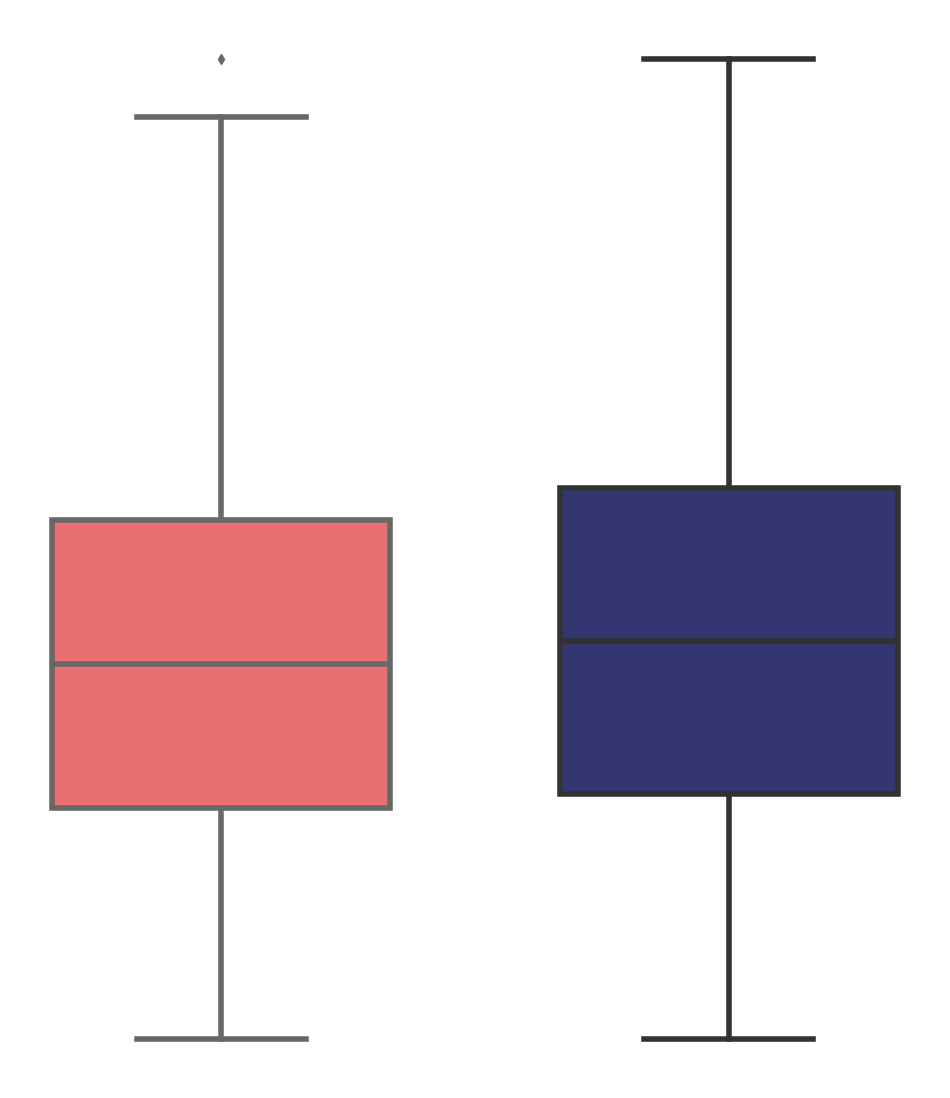

num_leaves
Mann-Whitney U test p-value: 0.0170
18530.0

Start num_leaves:
Mean: 8.9389
Variance: 3.9796

End num_leaves:
Mean: 8.4667
Variance: 3.6044
One-way ANOVA results for Start Nodes:
F=22.6228 p=0.00000
One-way ANOVA results for End Nodes:
F=24.1746 p=0.00000
One-way ANOVA results for Start v. End Nodes:
F=5.2631 p=0.02236

Full Model (Direction and Node):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0450      0.102     79.100      0.000       7.845       8.245
x1            -0.4722      0.160     -2.955      0.003      -0.787      -0.158
x2             2.4661      0.226     10.898      0.000       2.021       2.911
x3            -0.1089      0.226     -0.481      0.631      -0.554       0.336
x4            -1.3089      0.226     -5.784      0.000      -1.754      -0.864
x5             2.2411      0.226      9.903      0.000       1.796       2.686
x6

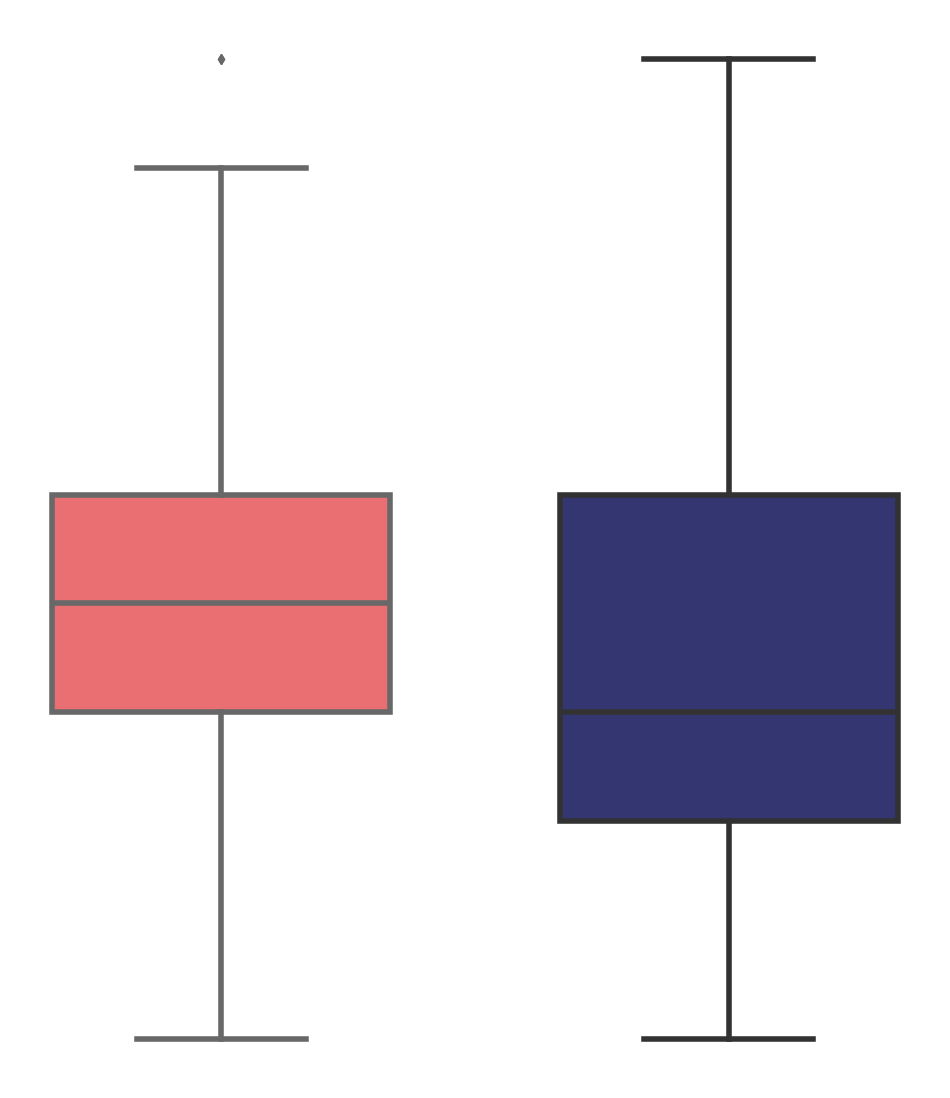

depth
Mann-Whitney U test p-value: 0.6866
16545.0

Start depth:
Mean: 3.8444
Variance: 0.3314

End depth:
Mean: 3.8167
Variance: 0.4164
One-way ANOVA results for Start Nodes:
F=8.8810 p=0.00000
One-way ANOVA results for End Nodes:
F=12.7132 p=0.00000
One-way ANOVA results for Start v. End Nodes:
F=0.1847 p=0.66761

Full Model (Direction and Node):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4600      0.038     89.960      0.000       3.384       3.536
x1            -0.0278      0.060     -0.460      0.646      -0.147       0.091
x2             0.7039      0.086      8.225      0.000       0.536       0.872
x3             0.0289      0.086      0.338      0.736      -0.139       0.197
x4            -0.0461      0.086     -0.539      0.590      -0.214       0.122
x5             0.5539      0.086      6.472      0.000       0.386       0.722
x6             0.4

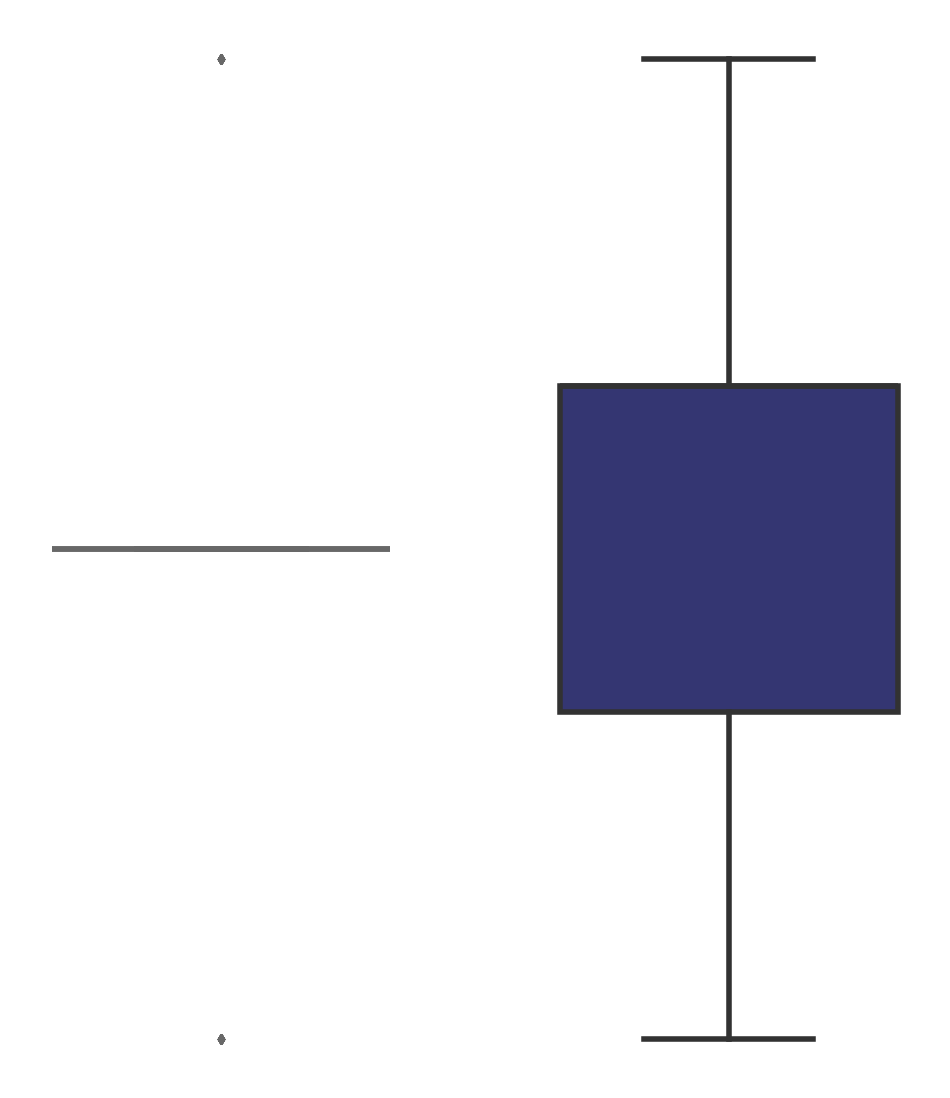

diameter
Mann-Whitney U test p-value: 0.0000
21730.5

Start diameter:
Mean: 6.5333
Variance: 1.1489

End diameter:
Mean: 5.8722
Variance: 0.8226
One-way ANOVA results for Start Nodes:
F=15.7053 p=0.00000
One-way ANOVA results for End Nodes:
F=19.2906 p=0.00000
One-way ANOVA results for Start v. End Nodes:
F=39.6841 p=0.00000

Full Model (Direction and Node):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.8800      0.054    108.108      0.000       5.773       5.987
x1            -0.6611      0.085     -7.735      0.000      -0.829      -0.493
x2             1.5506      0.121     12.813      0.000       1.313       1.789
x3             0.0756      0.121      0.624      0.533      -0.162       0.314
x4            -0.3494      0.121     -2.888      0.004      -0.587      -0.111
x5             1.1256      0.121      9.301      0.000       0.888       1.364
x6     

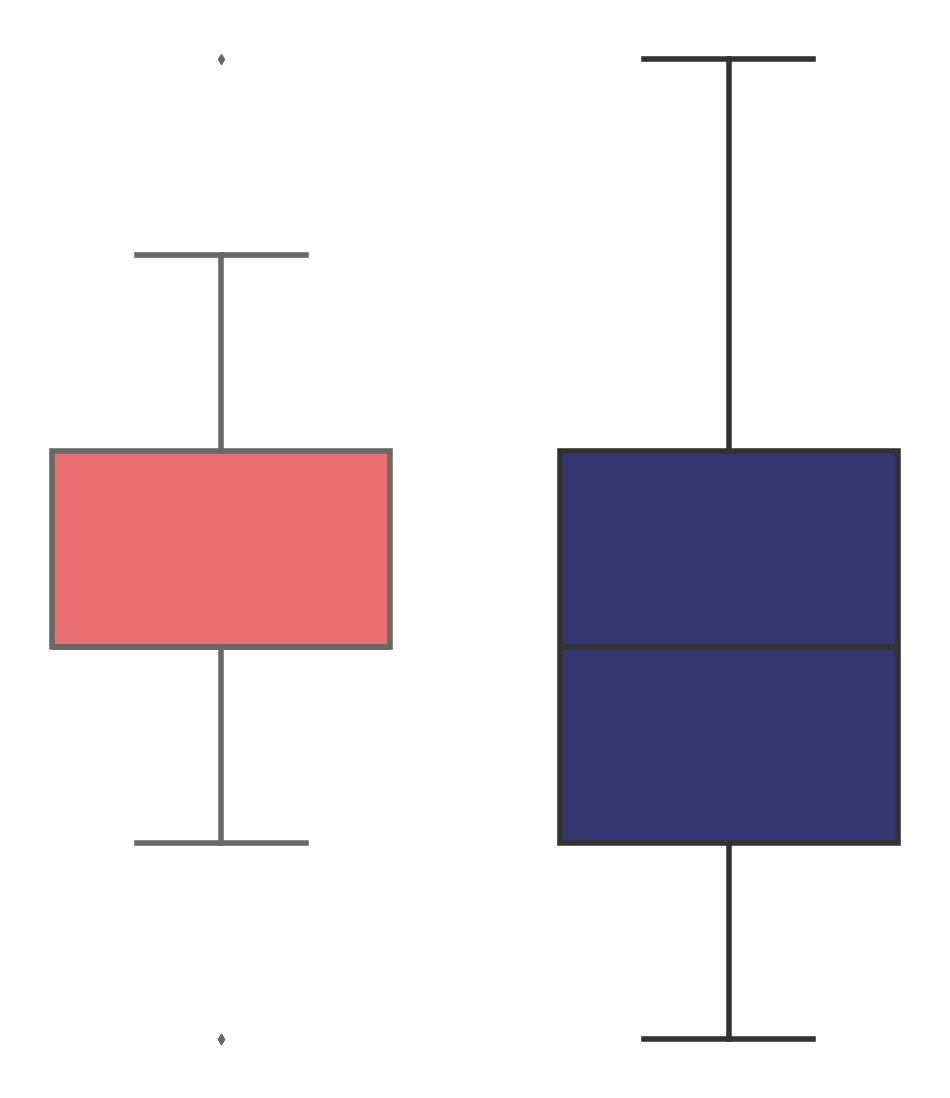

avg_branching
Mann-Whitney U test p-value: 0.4054
15380.5

Start avg_branching:
Mean: 1.8667
Variance: 0.0011

End avg_branching:
Mean: 1.8711
Variance: 0.0014
One-way ANOVA results for Start Nodes:
F=10.3956 p=0.00000
One-way ANOVA results for End Nodes:
F=27.1193 p=0.00000
One-way ANOVA results for Start v. End Nodes:
F=1.3512 p=0.24585

Full Model (Direction and Node):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6801      0.002    837.919      0.000       1.676       1.684
x1             0.0043      0.003      1.379      0.169      -0.002       0.011
x2             0.2058      0.004     46.120      0.000       0.197       0.215
x3             0.1657      0.004     37.150      0.000       0.157       0.175
x4             0.1490      0.004     33.397      0.000       0.140       0.158
x5             0.2023      0.004     45.357      0.000       0.194      

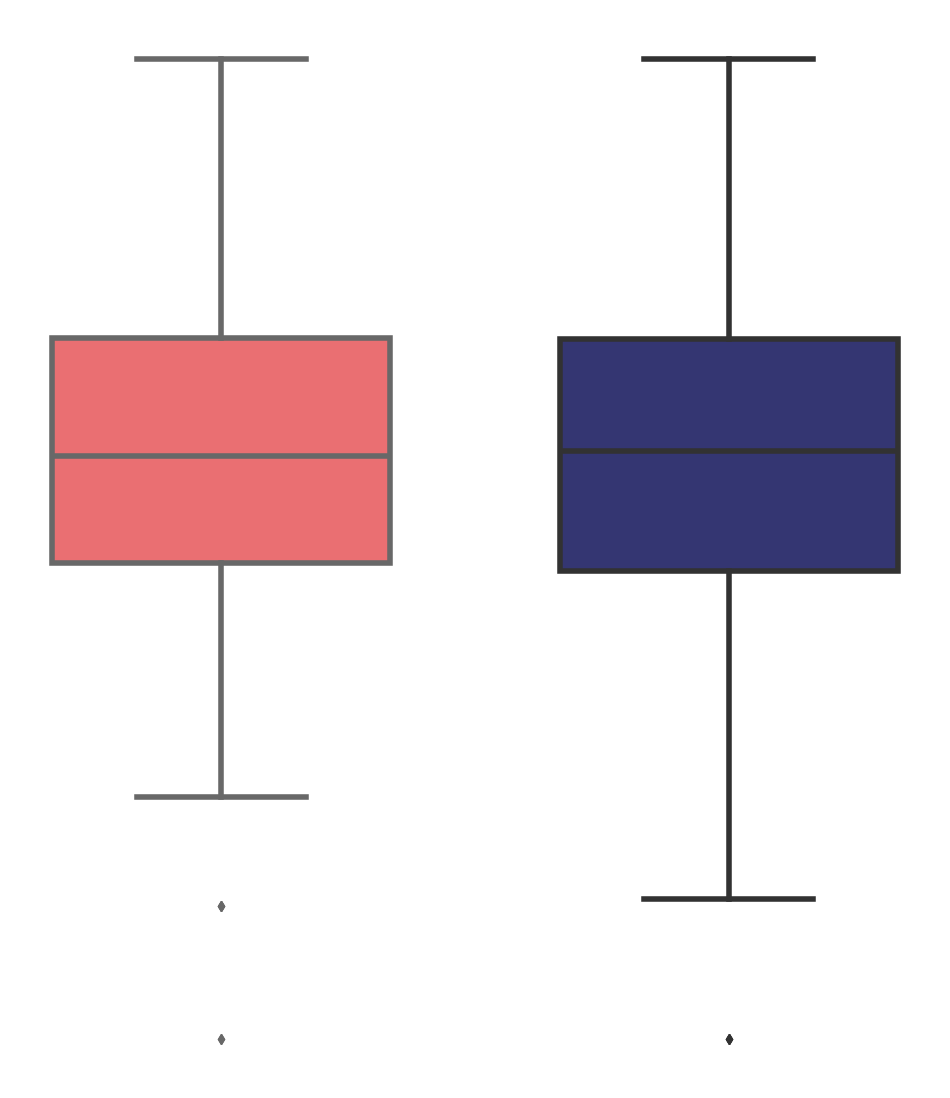

backbone_thickness
Mann-Whitney U test p-value: 0.1000
17681.0

Start backbone_thickness:
Mean: 0.2906
Variance: 0.0034

End backbone_thickness:
Mean: 0.2855
Variance: 0.0043
One-way ANOVA results for Start Nodes:
F=6.5464 p=0.00000
One-way ANOVA results for End Nodes:
F=4.8843 p=0.00002
One-way ANOVA results for Start v. End Nodes:
F=0.6264 p=0.42919

Full Model (Direction and Node):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2616      0.004     64.013      0.000       0.254       0.270
x1            -0.0052      0.006     -0.808      0.420      -0.018       0.007
x2             0.0010      0.009      0.111      0.912      -0.017       0.019
x3             0.0535      0.009      5.885      0.000       0.036       0.071
x4             0.0502      0.009      5.519      0.000       0.032       0.068
x5             0.0143      0.009      1.577      0.116     

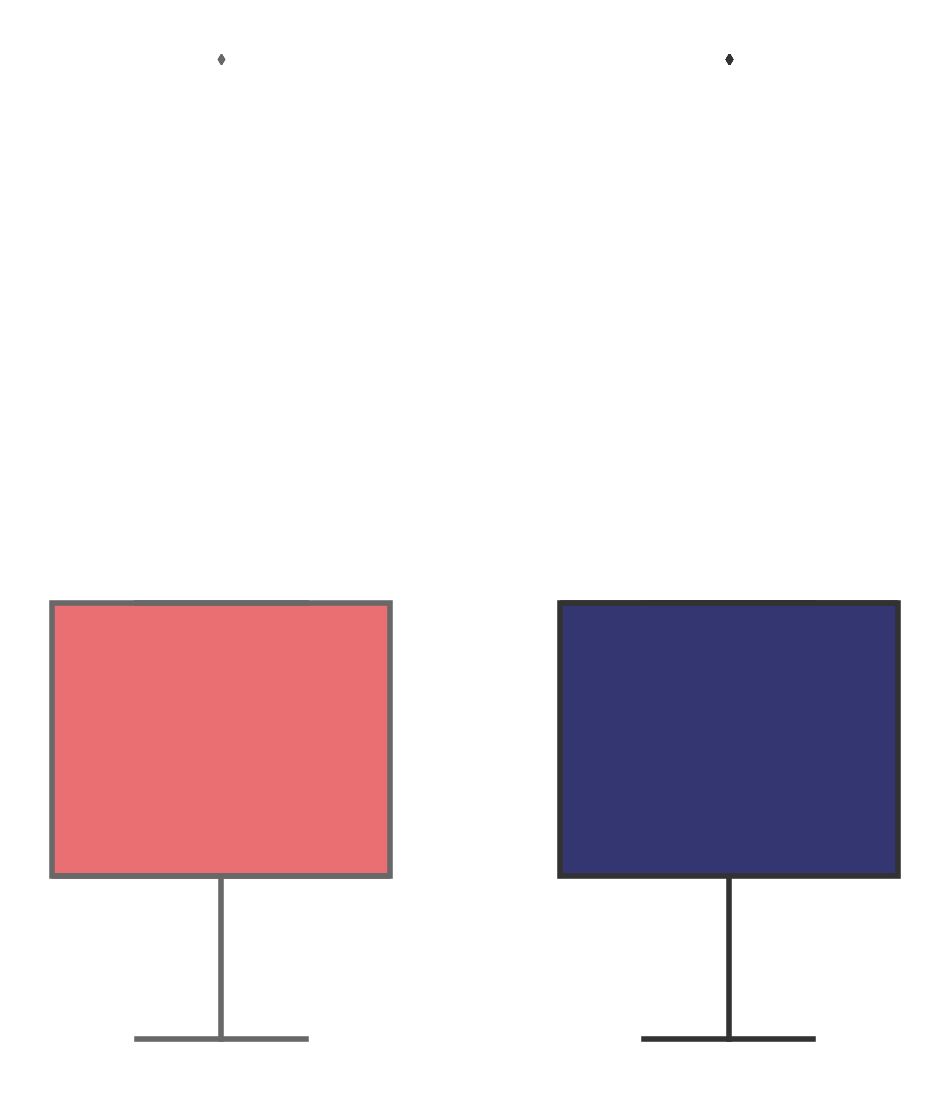

In [219]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm

for fn in ["num_nodes", "num_leaves", "depth", "diameter", "avg_branching", "backbone_thickness"]:
    feature = f"feature_{fn}"
    print(fn)

    # Split nodes into OBJECTS and non-OBJECTS
    start_features = []
    end_features = []
    for (node, reverse), group in all_tree_df.groupby(["node", "reverse"]):
        fts = group[feature]

        if reverse:
            end_features.extend(fts)
        else:
            start_features.extend(fts)

    # Perform statistical test
    stat, pval = stats.mannwhitneyu(start_features, end_features)
    print(f"Mann-Whitney U test p-value: {pval:.4f}")
    print(stat)
    # Print mean and variance for each group
    print(f"\nStart {fn}:")
    print(f"Mean: {np.mean(start_features):.4f}")
    print(f"Variance: {np.var(start_features):.4f}")

    print(f"\nEnd {fn}:") 
    print(f"Mean: {np.mean(end_features):.4f}")
    print(f"Variance: {np.var(end_features):.4f}")

    # Set up figure and grid
    fig = plt.figure(figsize=(12, 14))  # Wider figure to accommodate 9 subplots
    # gs = GridSpec(1, 18, figure=fig)#, height_ratios=[2,2,2,2,2,2,2,2,2,.2], hspace=.5)  # 1 row, 9 columns
    gs = GridSpec(1, 2, figure=fig)#, height_ratios=[2,2,2,2,2,2,2,2,2,.2], hspace=.5)  # 1 row, 9 columns


    # Store features for plotting
    all_features = []
    start_features = []
    end_features = []
    all_X_full = []
    all_y = []

    for rev in [1, 0]:
        for j, node in enumerate(OBJECTS):
            node_trees = all_tree_df[(all_tree_df["reverse"] == rev) & (all_tree_df["node"] == (node,))][feature]
            
            # print(rev, node)
            # print(node_trees)
            # print(all_tree_df)
            all_features.append(node_trees)
            if not rev: start_features.extend(node_trees)
            else: end_features.extend(node_trees)

            # One-hot encode nodes
            this = np.zeros(10)
            this[0] = rev
            this[j+1] = 1
            for ft in node_trees:
                all_X_full.append(this)
                all_y.append(ft) 

    start_groups = all_features[:9]
    f_stat_start, p_val_start = stats.f_oneway(*start_groups)

    print("One-way ANOVA results for Start Nodes:")
    print(f"F={f_stat_start:.4f} p={p_val_start:.5f}")

    rev_groups = all_features[9:]
    f_stat_rev, p_val_rev = stats.f_oneway(*rev_groups)

    print("One-way ANOVA results for End Nodes:")
    print(f"F={f_stat_rev:.4f} p={p_val_rev:.5f}")

    f_stat_comp, p_val_comp = stats.f_oneway(start_features, end_features)

    print("One-way ANOVA results for Start v. End Nodes:")
    print(f"F={f_stat_comp:.4f} p={p_val_comp:.5f}")

    # Run full model with both predictors
    all_X_full = np.vstack(all_X_full)
    all_X_full = sm.add_constant(all_X_full)
    all_y = np.array(all_y)

    # print(all_X_full.shape)
    # print(all_y.shape)

    # Fit full model
    model_full = sm.OLS(np.asarray(all_y, dtype=float), np.asarray(all_X_full, dtype=float)).fit()
    print("\nFull Model (Direction and Node):")
    print(model_full.summary().tables[1])

    print(f"\nFeature={fn}, Significant pairwise comparisons:")
    
    # # Prepare data for Tukey's test
    # start_data = test_df[['StartAt', 'accuracy']].copy()
    # # Perform Tukey's test
    tukey_start = pairwise_tukeyhsd(all_features, [x+"rev" for x in OBJECTS] + [x for x in OBJECTS] )
    # Print only significant differences
    summary = tukey_start.summary()
    # print(summary)
    significant_rows = [i for i, reject in enumerate(tukey_start.reject) if reject]
    if len(significant_rows) == 0: print("None")
    for row in significant_rows:
        print(summary[row])


    COLORS = ["#FF5A5F", "#2a2d7c"]
    # for j, rev in enumerate([True, False]):
    #     for i, node in enumerate(OBJECTS):
    #         ax = fig.add_subplot(gs[9*j+i])
    #         print(j,i)

    #         # print(all_features[j+2*i])
    #         print([x for x in all_features[j+2*i]])
    #         sns.boxplot(y=[x for x in all_features[j+2*i]], orient='v', color=COLORS[j], linewidth=4, ax=ax)

    #         ax.spines["top"].set_visible(False)
    #         ax.spines["right"].set_visible(False)
    #         ax.spines["left"].set_visible(False)
    #         ax.spines["bottom"].set_visible(False)
    #         ax.yaxis.set_visible(False)
    #         ax.xaxis.set_visible(False)
            
    #         ax.patch.set_visible(False)
    #         ax.set_facecolor('none') 

    for j, rev in enumerate([True, False]):
            ax = fig.add_subplot(gs[j])

            # ax = fig.add_subplot(gs[9*j+i])
            # print(j,i)

            # print(all_features[j+2*i])
            # print([x for x in all_features[j+2*i]])
            fff = []
            for i, node in enumerate(OBJECTS):
                 fff.extend([x for x in all_features[j+2*i]])
            sns.boxplot(y=fff, orient='v', color=COLORS[j], linewidth=4, ax=ax)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)
            ax.spines["bottom"].set_visible(False)
            ax.yaxis.set_visible(False)
            ax.xaxis.set_visible(False)
            
            ax.patch.set_visible(False)
            ax.set_facecolor('none') 
            

    # ax.xaxis.set_visible(True)

    # ax.spines["bottom"].set_visible(True)
    # ax.spines["bottom"].set_linewidth(2.5)
    # ax.spines['bottom'].set_position(('outward', 10))

    ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    # plt.xticks([0, 5, 10])
    plt.xlabel("")
    plt.show()

In [288]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm

sss = {x: [] for x in OBJECTS}
for fn in ["num_nodes", "num_leaves", "depth", "diameter", "avg_branching", "backbone_thickness"]:
    feature = f"feature_{fn}"
    print(fn)


    # Store features for plotting
    all_features = []
    start_features = []
    end_features = []
    all_X_full = []
    all_y = []

    
    for j, node in enumerate(OBJECTS):
        node_trees = all_tree_df[(~all_tree_df["reverse"]) & (all_tree_df["node"] == (node,))][feature]
        rev_node_trees = all_tree_df[(all_tree_df["reverse"]) & (all_tree_df["node"] == (node,))][feature]

        U, p = stats.mannwhitneyu(node_trees, rev_node_trees)
        print(f"{node} -- U={U:.4f} p={p:.5f}")
        if p < 0.05/(6*9):
            sss[node].append(fn)

num_nodes
O -- U=146.5000 p=0.14683
Y -- U=391.0000 p=0.00000
N -- U=66.0000 p=0.00027
K -- U=83.0000 p=0.00151
I -- U=264.5000 p=0.08068
W -- U=350.5000 p=0.00004
L -- U=209.5000 p=0.80508
A -- U=284.0000 p=0.02319
P -- U=293.5000 p=0.01136
num_leaves
O -- U=159.0000 p=0.26146
Y -- U=376.0000 p=0.00000
N -- U=81.5000 p=0.00101
K -- U=96.5000 p=0.00470
I -- U=270.0000 p=0.05519
W -- U=322.0000 p=0.00070
L -- U=150.5000 p=0.17350
A -- U=247.5000 p=0.19370
P -- U=306.5000 p=0.00366
depth
O -- U=115.0000 p=0.00458
Y -- U=315.0000 p=0.00046
N -- U=63.0000 p=0.00004
K -- U=89.5000 p=0.00093
I -- U=170.0000 p=0.37467
W -- U=273.5000 p=0.02184
L -- U=259.5000 p=0.06258
A -- U=259.0000 p=0.06638
P -- U=187.0000 p=0.71025
diameter
O -- U=236.5000 p=0.30262
Y -- U=384.0000 p=0.00000
N -- U=150.0000 p=0.13907
K -- U=210.5000 p=0.77089
I -- U=259.5000 p=0.08756
W -- U=369.0000 p=0.00000
L -- U=276.0000 p=0.03055
A -- U=281.5000 p=0.02273
P -- U=292.5000 p=0.00970
avg_branching
O -- U=146.5000 p=0.

In [289]:
for node in sss:
    print(node, sss[node])

O []
Y ['num_nodes', 'num_leaves', 'depth', 'diameter', 'avg_branching']
N ['num_nodes', 'depth', 'avg_branching', 'backbone_thickness']
K []
I []
W ['num_nodes', 'num_leaves', 'diameter']
L []
A []
P []


### STOP HERE?

In [ ]:
# ADD REVERSE ONES

# Generate trees for end nodes
test_df['ending_node'] = test_df['paths'].apply(lambda x: x[-1])
for traj_type, df_subset in [
    ('all', test_df),
    ('winner', test_df[test_df['ending_node'] == test_df['EndAt']]),
    ('loser', test_df[test_df['ending_node'] != test_df['EndAt']])
]:
    for end_node, group in df_subset.groupby(['ending_node']):
        if end_node[0] not in OBJECTS:
            continue
        mean_acc = np.mean(group['path_mean_acc'])
        trees = generate_bootstrap_trees(group, reverse_trajs=True)
        
        tree_df = pd.concat([tree_df, pd.DataFrame({
            'node_type': ['end'] * len(trees),
            'node': [end_node] * len(trees),
            'trajectory_type': [traj_type] * len(trees),
            'mean_accuracy': [mean_acc] * len(trees),
            'trees': trees
        })], ignore_index=True)


## 3. Plot node Flow Trees

## 3b. Generate bootstrapped trees

58.0
58 58


In [122]:
## Make node trees for everything
# Create empty DataFrame to store all tree information
all_tree_df = pd.DataFrame(columns=[
    'node',           # the actual node label
    'trees'           # list of bootstrapped trees
])

def process_path(path):
    states = path.split()
    states[-1] = "."+states[-1]
    states = collapse_traj(states)
    return(states)

trajs = [process_path(x) for x in test_df["paths"]]

traj_dict = {x: [] for x in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"}

for traj in trajs:
    for i in range(len(traj)-8): # want min path length 4/5
        traj_dict[traj[i]].append(traj[i:i+7])

k_fold = 20
for node in traj_dict:
    trees = []
    for _ in range(k_fold):
        sampled_trajs = traj_dict[node]
        if len(sampled_trajs) > 20:
            sampled_indices = np.random.choice(len(sampled_trajs), size=20, replace=False)
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
        else:
            print(len(sampled_trajs))
        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)

    all_tree_df = pd.concat([all_tree_df, pd.DataFrame({
        'node': [(node,)] * len(trees), 
        'trees': trees
    })], ignore_index=True)
# all_tree_df

18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18


## 4. Featurise / embed them

### Tree features

In [123]:




# Extract features for each tree
all_feature_names = None
all_features = []

for tree in tree_df["trees"]:
    # Get root node (any node with no incoming edges)
    root = 0
    
    # Extract features for this tree
    feature_names, features = extract_tree_features(tree, root)
    
    # Store feature names once
    if all_feature_names is None:
        all_feature_names = feature_names
        
    all_features.append(features)

# Convert to numpy array
tree_features = np.array(all_features)

# Add feature columns to dataframe
for i, name in enumerate(all_feature_names):
    tree_df[f"feature_{name}"] = tree_features[:,i]


### Tree embeddings

In [124]:
node_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
node_flow_tree_embedder.fit(np.array(tree_df["trees"]))

# Extract features for each tree
all_embeddings = []

# Get embeddings for each tree
tree_embeddings = node_flow_tree_embedder.infer(np.array(tree_df["trees"]))

# Add single column with full embedding vector
tree_df["embedding"] = [emb for emb in tree_embeddings]

In [ ]:
# # Get all start node winner trees
# start_winners = tree_df[(tree_df['node_type'] == 'start') & (tree_df['trajectory_type'] == 'winner')]

# # Get trees for a specific end node
# node_trees = tree_df[tree_df['node'] == ('A',)]

# # Sort by accuracy
# sorted_trees = tree_df.sort_values('mean_accuracy', ascending=False)


## 5. Cluster them

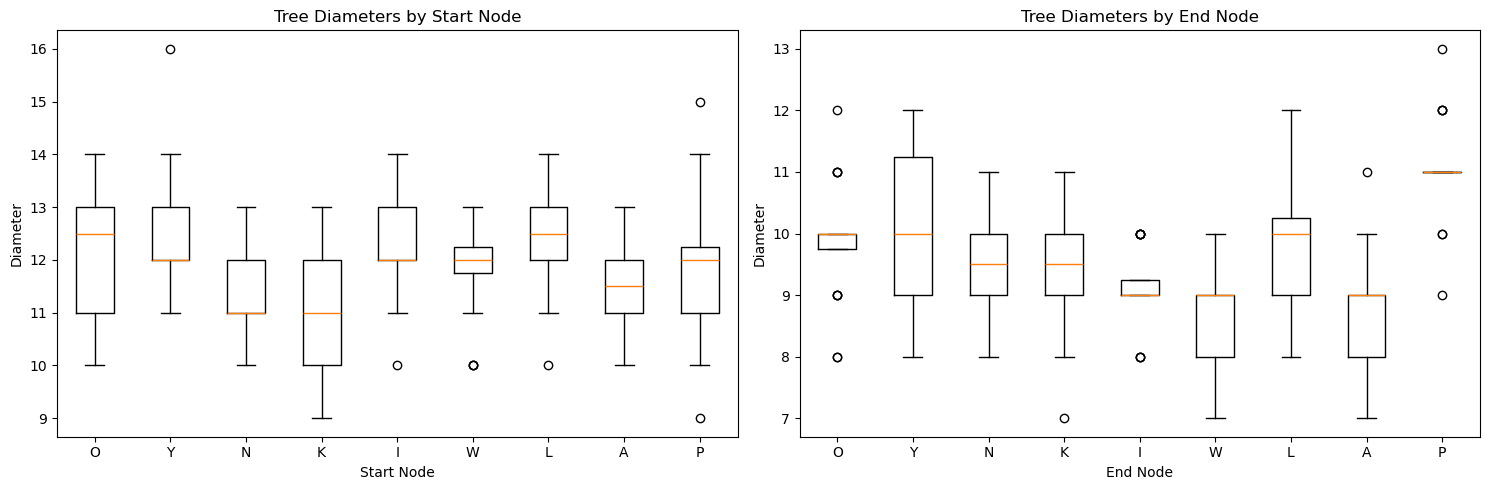

In [125]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot for start nodes
start_trees = tree_df[(tree_df['node_type'] == 'start') & (tree_df["trajectory_type"] == "all")]
start_nodes = start_trees['node'].unique()

start_diameters = []
start_node_labels = []
for node in OBJECTS:
    node = (node,)
    node_trees = start_trees[start_trees['node'] == node]
    diameters = node_trees['feature_diameter']
    start_diameters.append(diameters)
    start_node_labels.extend([str(node[0])] * len(diameters))

ax1.boxplot(start_diameters, labels=[str(n[0]) for n in OBJECTS])
ax1.set_title('Tree Diameters by Start Node')
ax1.set_xlabel('Start Node')
ax1.set_ylabel('Diameter')

# Plot for end nodes 
end_trees = tree_df[(tree_df['node_type'] == 'end') & (tree_df["trajectory_type"] == "all")]
end_nodes = end_trees['node'].unique()

end_diameters = []
end_node_labels = []
for node in OBJECTS:
    node = (node,)
    node_trees = end_trees[end_trees['node'] == node]
    diameters = node_trees['feature_diameter']
    end_diameters.append(diameters)
    end_node_labels.extend([str(node[0])] * len(diameters))

ax2.boxplot(end_diameters, labels=[str(n[0]) for n in OBJECTS])
ax2.set_title('Tree Diameters by End Node')
ax2.set_xlabel('End Node') 
ax2.set_ylabel('Diameter')

plt.tight_layout()
plt.show()
